<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет, Михаил! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Комментарий студента</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Привет, Павел! Спасибо за проверку моего проекта и за то, что поделился опытом — это очень ценно. С удовольствием общаемся на «ты» :)
<br>Я оставил свои пояснения под твоими комментариями — постарался учесть каждое замечание.</span>

# 🏨 «Прогнозирование отмен бронирований в сети отелей UrbanStay: ML‑подход к повышению загрузки»

Автор: Якунин Михаил

Дата: "16" сентября 2026 г.

***По этой ссылке можно посмотреть проект и скачать последнюю версию: https://github.com/MEYakunin/Sprint17_Booking_Cancellation_Predict.git***

## Цель проекта

Разработать модель машинного обучения, прогнозирующую вероятность отмены бронирования в сети отелей **UrbanStay**, и оценить её экономическую эффективность. Внедрение такой модели позволит заказчику заранее выявлять рискованные бронирования, принимать превентивные меры для их сохранения и своевременно повторно сдавать номера, что снизит долю отмен бронирований в последний момент с ~30% до 10% и повысит загрузку отелей до 80% и более.

Для достижения цели планируется:

1. Подготовить данные: загрузить таблицы `hotel_bookings` и `hotel_reviews`, провести `EDA`, устранить дубликаты и аномалии, объединить таблицы и создать новые признаки (включая признаки на основе текстов отзывов).
2. Обучить и сравнить не менее двух моделей (`CatBoost`, `LightGBM`) с оптимизацией гиперпараметров в `Optuna`, выбрать лучшую по ключевой бизнес-метрике `Incremental Revenue (IR)`.
3. Откалибровать лучшую модель, подобрать оптимальный порог классификации и оценить важность признаков.
4. Рассчитать экономический эффект внедрения модели по трём показателям: прирост дохода (`IR`), динамика доли отмен бронирования и динамика загрузки отеля — и проверить достижение целевых `KPI` (доля отмен ≤ 10%, падение загрузки не более 8%, относительный `IR` ≥ 50%).

## Задача проекта

1. *Разработать ML-модель*, прогнозирующую вероятность отмены бронирования в сети отелей `UrbanStay` по входным данным о брони (канал продаж, состав гостей, история клиента, стоимость, срок до заезда и др.) и данным отзывов. Модель должна минимизировать финансовые потери сети отелей и по возможности повышать загрузку номеров: она позволит заранее выявлять рискованные бронирования и принимать решение о повторном бронировании номера или сохранении брони.

2. *Оценить экономическую эффективность модели* по трём показателям:
   - динамика доли отмен бронирования;
   - динамика загрузки отелей;
   - прирост дохода благодаря модели (`Incremental Revenue`, `IR`).

3. *Достичь целевых показателей*:
   - доля отмен бронирования после внедрения модели — не более 10%;
   - загрузка отеля не должна снизиться более чем на 8% относительно уровня до внедрения;
   - относительный `IR` — не менее 50%.

## Описание данных

Для проекта используются два источника данных, выгруженных из базы данных PostgreSQL с помощью SQL-запросов.

**Таблица `hotel_bookings`** — данные об истории бронирований номеров (35 341 запись). Каждая строка — отдельная бронь:

- `booking_id` — уникальный номер брони;
- `booking_date` — дата оформления брони;
- `sales_channel` — способ оформления брони: офлайн_бронирование, онлайн_бронирование, корпоративное_бронирование;
- `adult_count` — количество взрослых гостей;
- `child_count` — количество детей;
- `returning_customer` — отметка о том, что клиент уже бронировал номера в сети отелей;
- `previous_cancellations` — количество отменённых бронирований у клиента в прошлом;
- `previous_no_shows` — количество несостоявшихся заездов в прошлом;
- `booking_value` — итоговая стоимость бронирования в рублях;
- `days_until_checkin` — количество дней с момента брони до даты заселения;
- `weekend_nights` — количество ночей проживания, приходящихся на выходные дни;
- `weekday_nights` — количество ночей проживания, приходящихся на будние дни;
- `meal_plan` — выбранный гостями тип питания;
- `parking_included` — информация о бронировании парковочного места;
- `room_type` — категория номера или номеров в брони;
- `customer_special_requests` — количество комментариев и пожеланий клиента;
- `booking_status` — целевая переменная: `отказ_брони` (бронь отменена) / `нет_отказа` (бронь активна).

**Таблица `hotel_reviews`** — данные по истории отзывов о проживании (25 177 отзывов):

- `customer_id` — уникальный идентификатор клиента;
- `booking_id` — идентификатор брони, по которой оставлен отзыв;
- `review_date` — дата, когда клиент оставил отзыв;
- `stay_rating` — оценка проживания: от 1 (низший балл) до 5 (высший балл);
- `review_text` — развёрнутый текстовый комментарий клиента о проживании.

## Содержание <a id="content"></a>

* [1. Подготовка данных](#1)
  * [1.1. Подготовка среды и библиотек](#1_1)
  * [1.2. Загрузка данных](#1_2)
  * [1.3. Исследовательский анализ данных и предобработка](#1_3)
  * [1.4. Объединение таблиц](#1_4)
  * [1.5. Создание новых признаков](#1_5)
  * [1.6. Анализ итоговой таблицы](#1_6)
  * [1.7. Промежуточный итог](#1_7)
* [2. Моделирование](#2)
  * [2.1. Обучение базовых моделей](#2_1)
  * [2.2. Калибровка модели и пересчёт результатов](#2_2)
  * [2.3. Поиск порога классификации](#2_3)
  * [2.4. Анализ матрицы классификаций](#2_4)
  * [2.5. Фиксирование итоговой модели](#2_5)
  * [2.6. Анализ важности признаков](#2_6)
  * [2.7. Промежуточный итог](#2_7)
* [3. Расчёт экономической эффективности модели](#3)
  * [3.1. Подготовка данных для расчётов](#3_1)
  * [3.2. Расчёт показателей до и после внедрения модели](#3_2)
  * [3.3. Проверка целевых KPI](#3_3)
  * [3.4. Промежуточный итог](#3_4)
* [4. Выводы по проекту](#4)
  * [4.1. Выводы о проделанной работе](#4_1)
  * [4.2. Выводы по анализу эффективности модели](#4_2)



## [Этап 1: Подготовка данных <a id=1></a>](#content)

### [1.1 Подготовка среды и библиотек <a id=1_1></a>](#content)

In [70]:
# Установка необходимых библиотек
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Стандартные библиотеки
import re

# Сторонние библиотеки
import lightgbm as lgb
import matplotlib as mpl
import matplotlib.pyplot as plt
import nltk
import numpy as np
import optuna
import pandas as pd
import seaborn as sns

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from nltk.corpus import stopwords
from optuna.pruners import MedianPruner
from phik.report import plot_correlation_matrix
from sqlalchemy import create_engine

from sklearn.base import clone
from sklearn.calibration import (
    CalibratedClassifierCV,
    CalibrationDisplay,
    calibration_curve,
)
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.frozen import FrozenEstimator
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import KFold, StratifiedKFold, TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    StandardScaler,
)

# Загрузка стоп-слов NLTK (однократно при первом запуске)
nltk.download('stopwords')

d:\ProjectPython\Sprint17_Booking_Cancellation_Predict\.ml_env_sprint17\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mikhail.yakunin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Импорты собраны в одной ячейке, разделены на функциональные группы пустой строкой.</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color="red">Все зависимомсти нужно явно установить до импортов, что бы код полностью воспроизводился в JupyterHub Практикума.</font>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Я раскомментировал строку кода в ячейке для установки зависимостей.</span>

In [3]:
# Устанавка константных параметров
RANDOM_STATE = 42
TEST_SIZE = 0.2
AVG_REV = 64500
COST_FP = 7000
LOST_REV = 64500
PER_REBOOKING = 45000
EARLY_STOPPING_ROUNDS = 20

# Целевые показатели по условию проекта
TARGET_CANCEL_SHARE = 0.10
MAX_OCCUPANCY_DROP = 0.08
MIN_RELATIVE_IR = 0.5

# Параметры для подключения к данным PostgreSQL 
db_config = {
    'user': 'praktikum_student',
    'pwd': 'Sdf4$2;d-d30pp', 
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': '6432', 
    'db': 'data-scientist-hotels' 
} 

In [4]:
# Настройки Pandas для отображения DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}'.replace(',', ' '))
pd.set_option('display.memory_usage', True)

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# Отключает научную нотацию (экспоненциальную запись) на оси Y для всех графиков
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.limits'] = [-99, 99]

# Подавляем INFO-сообщения Optuna, оставляем только предупреждения и ошибки 
optuna.logging.set_verbosity(optuna.logging.WARNING)

### [1.2 Загрузка данных <a id=1_2></a>](#content)

In [5]:
# Создаем подключение к БД
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
) 

query_bookings = '''
SELECT *
FROM hotel_bookings
'''
query_reviews = '''
SELECT *
FROM hotel_reviews
'''

engine = create_engine(connection_string)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Да, запрос не сложный )</font>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Я тут решил пойти самым простым путем, так как не заходтел тратить время на вспоминие SQL и писать запрос который сразу выгрузит объеденненую таблицу. Но меня не покидает мысль, что в релальных проектах лучше и проще производить объединение таблиз на уровне запроса к БД. Можешь подскзать как на самом деле или каким способом чаще полузуются в реальности?</span>

In [6]:
# Извлекаем данные из БД
df_bookings = pd.read_sql_query(query_bookings, con=engine)
df_reviews = pd.read_sql_query(query_reviews, con=engine)

# Создание словаря c датафреймами
dataframes = {
    'bookings': df_bookings,
    'reviews': df_reviews
}

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'> В Pandas есть метод `pd.read_sql` в который можно передать или запрос или название таблицы если забирается вся таблица.</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Я попробовал такой вариант импорта данных, но у меня почему-то на этапе обучение базовых моделей через кросс-валидацию выдавалась ошибка: <br>`TypeError: Feature names are only supported if all input features have string names, but your input has ['quoted_name', 'str'] as feature name / column name types.` <br>Я попытался испраить, но что-то не вышло у меня. Поэтому я оставлю такой вариант.
</span>


In [7]:
# Создаем функцию для отображения данных
def primary_info(df, name):
    """
    Выводит базовую сводную информацию о DataFrame: заголовок с именем таблицы,
    первые 5 строк, сводку типов и пропусков, а также описательную статистику.
    """
    print('='*50)
    print(f'Информация о таблице: {name}')
    print('='*50)
    display(df.head(5))
    df.info()
    display(df.describe(include='all').T)
    print()

In [8]:
# Выводим первичную информацию 
for name, df in dataframes.items():
    primary_info(df, name)

Информация о таблице: bookings


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6 700.000,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62 300.000,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46 900.000,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53 600.000,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46 900.000,96,5,2,тип_питания_1,False,тип_1,1


<class 'pandas.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  str    
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  str    
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  str    
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan                  35341 non-null  str    
 14  p

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,35341,30733,INN00327,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_date,35341,2445,2019-06-03,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_channel,35341,3,офлайн_бронирование,12040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_count,35 341.000,NaN,NaN,NaN,12.480,45.726,1.000,1.000,2.000,3.000,300.000
child_count,35 341.000,NaN,NaN,NaN,0.359,0.587,0.000,0.000,0.000,1.000,2.000
returning_customer,35341,2,True,19928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous_cancellations,35 341.000,NaN,NaN,NaN,0.357,0.629,0.000,0.000,0.000,1.000,5.000
previous_no_shows,35 341.000,NaN,NaN,NaN,0.840,0.932,0.000,0.000,1.000,1.000,5.000
booking_status,35341,2,нет_отказа,25177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_value,35 341.000,NaN,NaN,NaN,61 634.055,42 837.590,0.000,33 500.000,53 600.000,80 400.000,417 221.200



Информация о таблице: reviews


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


<class 'pandas.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  25177 non-null  str   
 1   booking_id   25177 non-null  str   
 2   review_date  25177 non-null  object
 3   stay_rating  25177 non-null  int64 
 4   review_text  25177 non-null  str   
dtypes: int64(1), object(1), str(3)
memory usage: 983.6+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,25177,13429,C4486,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_id,25177,21883,INN01741,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_date,25177,2514,2020-06-12,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stay_rating,25 177.000,NaN,NaN,NaN,3.395,0.541,2.000,3.000,3.000,4.000,5.000
review_text,25177,14153,Отличный отель! хорошие виды из окон.,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Данные загружены корректно, первичный осмотр проведен.</font>

### [1.3 Исследовательский анализ данных и предобработка <a id=1_3></a>](#content)

#### Анализ дубликатов

In [9]:
# Приводим тип данных у признаков с датами
df_bookings['booking_date'] = pd.to_datetime(df_bookings['booking_date'])
df_reviews['review_date'] = pd.to_datetime(df_reviews['review_date'])

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> 👍</font>

In [10]:
# Определянем функцию для выявления дубликатов в датасете
def duplicate_search(df_bookings, df_reviews):
    """
    Определяем все дубликаты строк и выводим их количество
    """
    # Определяем дубликаты
    bookings_dupl = df_bookings.duplicated(subset=['booking_id']).sum()
    reviews_dupl = df_reviews.duplicated(subset=['customer_id', 'booking_id', 'review_date']).sum()

    print("Дубликаты bookings:", bookings_dupl)
    print("Дубликаты reviews:", reviews_dupl)

In [11]:
# Выводим информацию об дубликатах
duplicate_search(df_bookings, df_reviews)

Дубликаты bookings: 4608
Дубликаты reviews: 130


In [12]:
# Удаляем дублирующие строки
df_bookings_drop_dupl = df_bookings.drop_duplicates(subset=['booking_id'])
df_reviews_drop_dupl = df_reviews.drop_duplicates(subset=['customer_id', 'booking_id', 'review_date'])

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Отлично! Удалили явные дубликаты.</font>

In [13]:
# Выводим информацию об дубликатах после очистки датасетов
duplicate_search(df_bookings_drop_dupl, df_reviews_drop_dupl)

Дубликаты bookings: 0
Дубликаты reviews: 0


#### Анализ числовых признаков

In [14]:
# Определяем числовые признаки
numeric_cols_booking = df_bookings_drop_dupl.select_dtypes(np.number).columns.to_list()
numeric_cols_reviews = df_reviews_drop_dupl.select_dtypes(np.number).columns.to_list()

In [15]:
# Функция вывода графика гистограммы
def print_histplot(df, column, ax):
    """
    Строит гистограмму распределения значений столбца с наложенной KDE-кривой,
    а также добавляет вертикальные линии для среднего и медианы с подписями.
    """
    # Гистограмма с KDE 
    sns.histplot(df[column], bins=100, kde=True, 
                color='steelblue', edgecolor='black', label='Гистограмма', ax=ax)

    # Получаем линию KDE и меняем её цвет
    for line in ax.lines:
        line.set_color('red')
        line.set_linewidth(2)
        line.set_label('KDE')

    # Добавляем вертикальные линии для среднего и медианы
    ax.axvline(df[column].mean(), color='green', linestyle='--', linewidth=2, 
            label=f'Среднее: {df[column].mean():,.2f} руб.')
    ax.axvline(df[column].median(), color='orange', linestyle='--', linewidth=2, 
            label=f'Медиана: {df[column].median():,.2f} руб.')

    # Подписываем оси и добавляем заголовок
    ax.set_ylabel('Плотность', fontsize=15)
    ax.set_title(f'Распределение\n для данных {column}', fontsize=20, fontweight='bold')
    ax.legend(fontsize=11)

In [16]:
# Функция вывода графика ящик с усами
def print_boxplot(df, column, ax):
    """
    Строит boxplot («ящик с усами») для заданного столбца DataFrame
    """
    # Boxplot (ящик с усами)
    ax.boxplot(df[column], vert=True, patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='navy'),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(color='navy', linewidth=2),
        capprops=dict(color='navy', linewidth=2),
        flierprops=dict(markerfacecolor='red', marker='o', markersize=6)
    )

    ax.set_title(f'Boxplot для {column}', fontsize=20, fontweight='bold')
    ax.set_ylabel('Значение', fontsize=15)
    ax.grid(True, alpha=0.3, axis='y')

    # Вычисляем ключевые статистики для аннотаций 
    q1 = df[column].quantile(0.25) 
    q3 = df[column].quantile(0.75) 
    median = df[column].median()

    # Размещаем текстовые аннотации
    ax.text(
        x=1.1, # Координата X (слева от бокса) 
        y=ax.get_ylim()[1] * 0.7, # Первая строка сверху 
        s=f'Q3: {q3}\nMedian: {median:.2f}\nQ1: {q1}\n',
        fontsize=15
    )

In [17]:
# Функция вывода графика распределения
def print_countplot(df, column, ax, hue=None, palette=None):
    """
    Строит countplot для заданного столбца DataFrame
    """
    if df[column].nunique() > 50:
        return

    # Распределение countplot
    sns.countplot(data=df, x=column, color='steelblue', ax=ax, hue=hue, palette=palette)

    ax.set_title(f'Распределение\n по количеству для {column}', fontsize=20, fontweight='bold')
    ax.set_ylabel('Количество', fontsize=15)

    # Добавляем значения над столбцами
    for container in ax.containers:
        ax.bar_label(container, padding=3, rotation=90, fontsize=9)

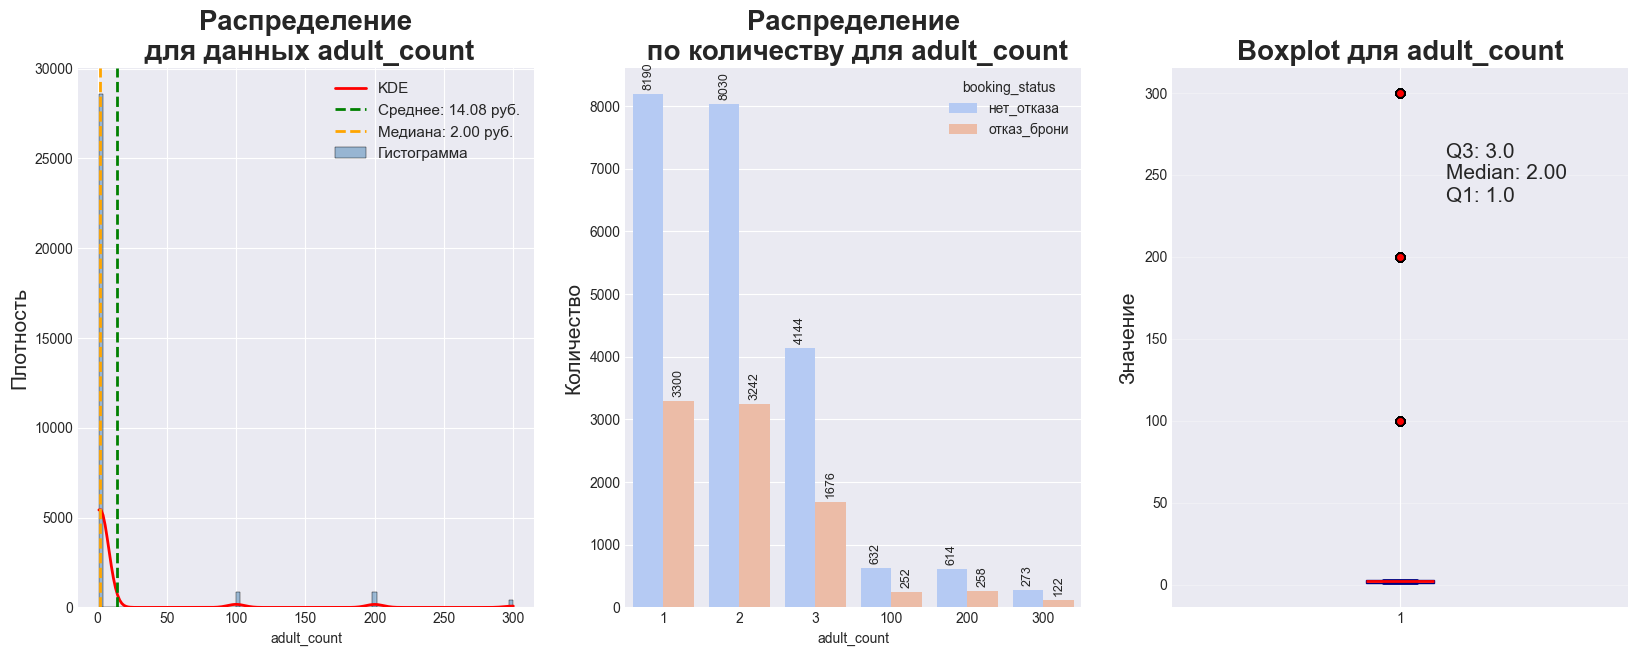

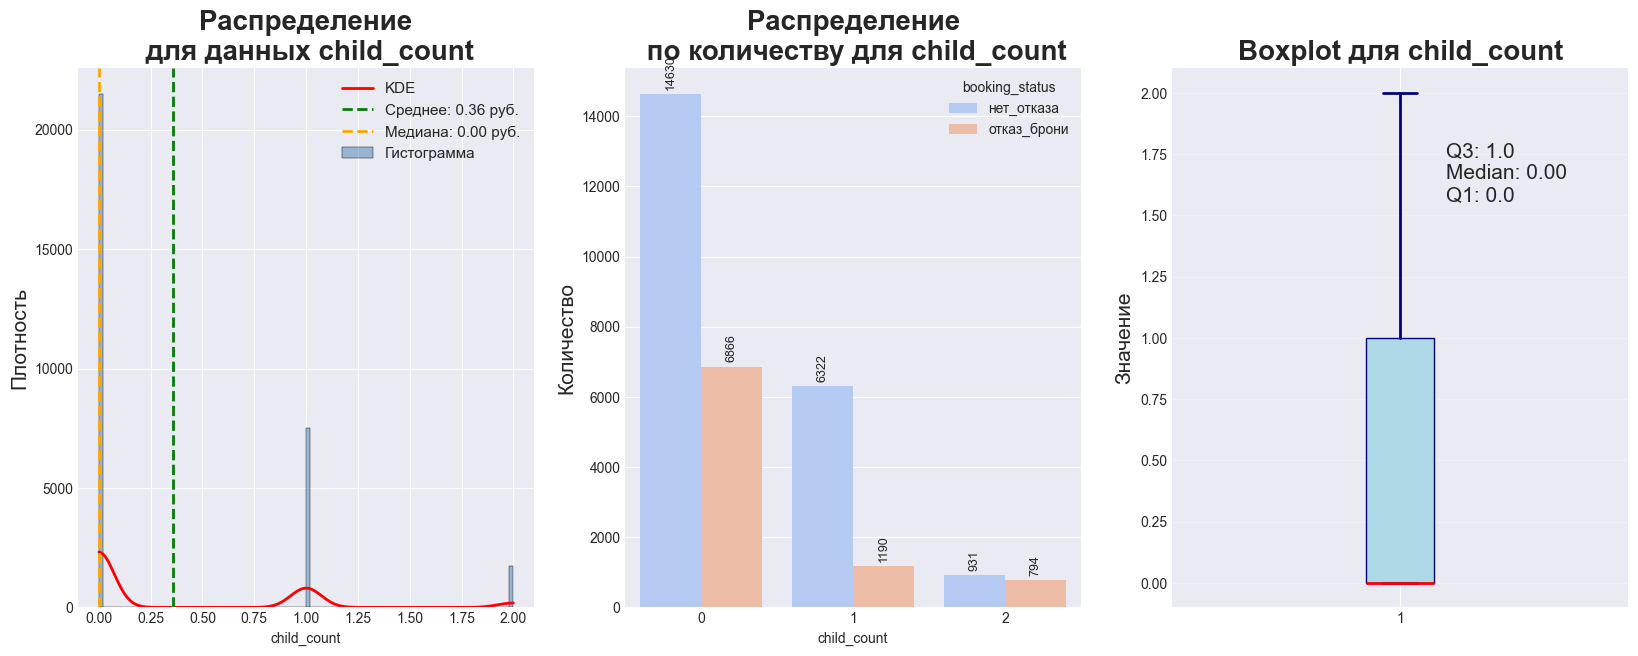

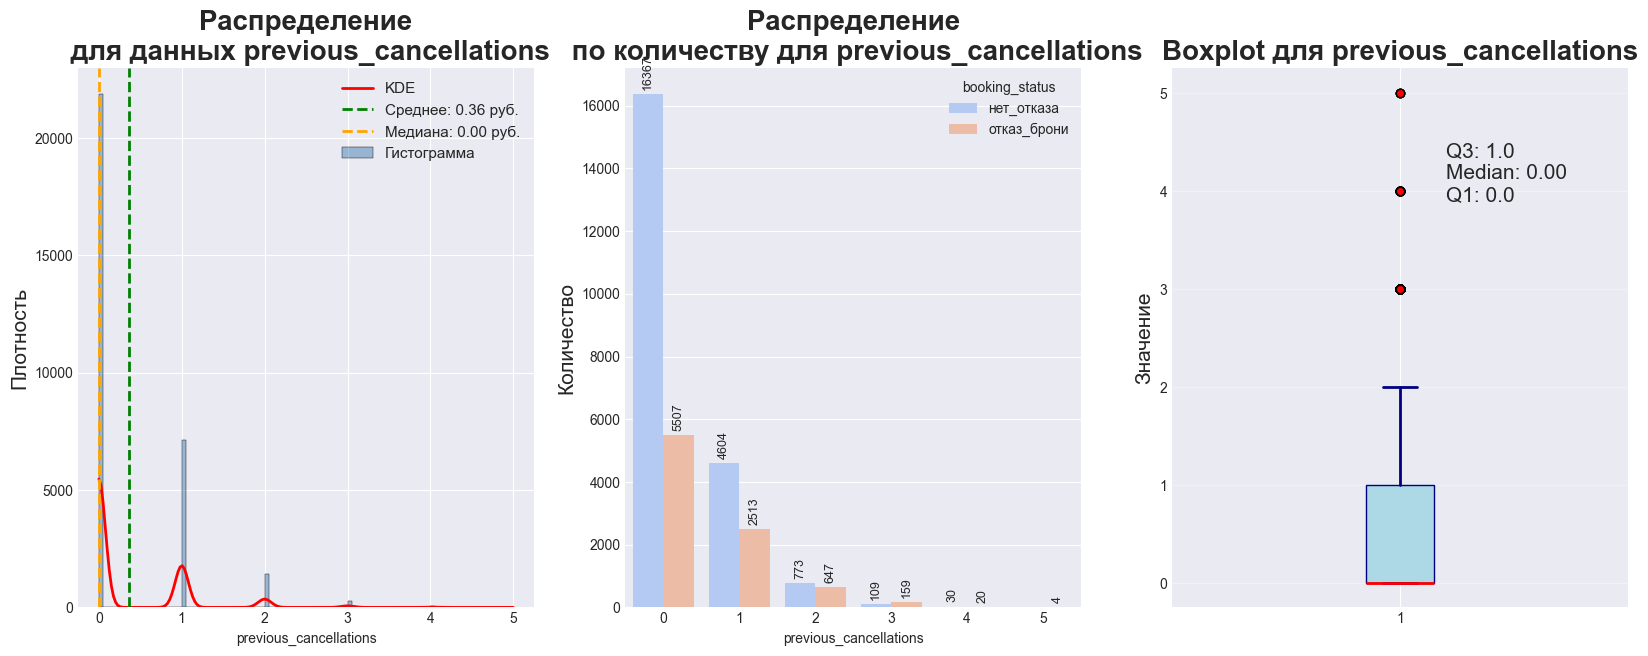

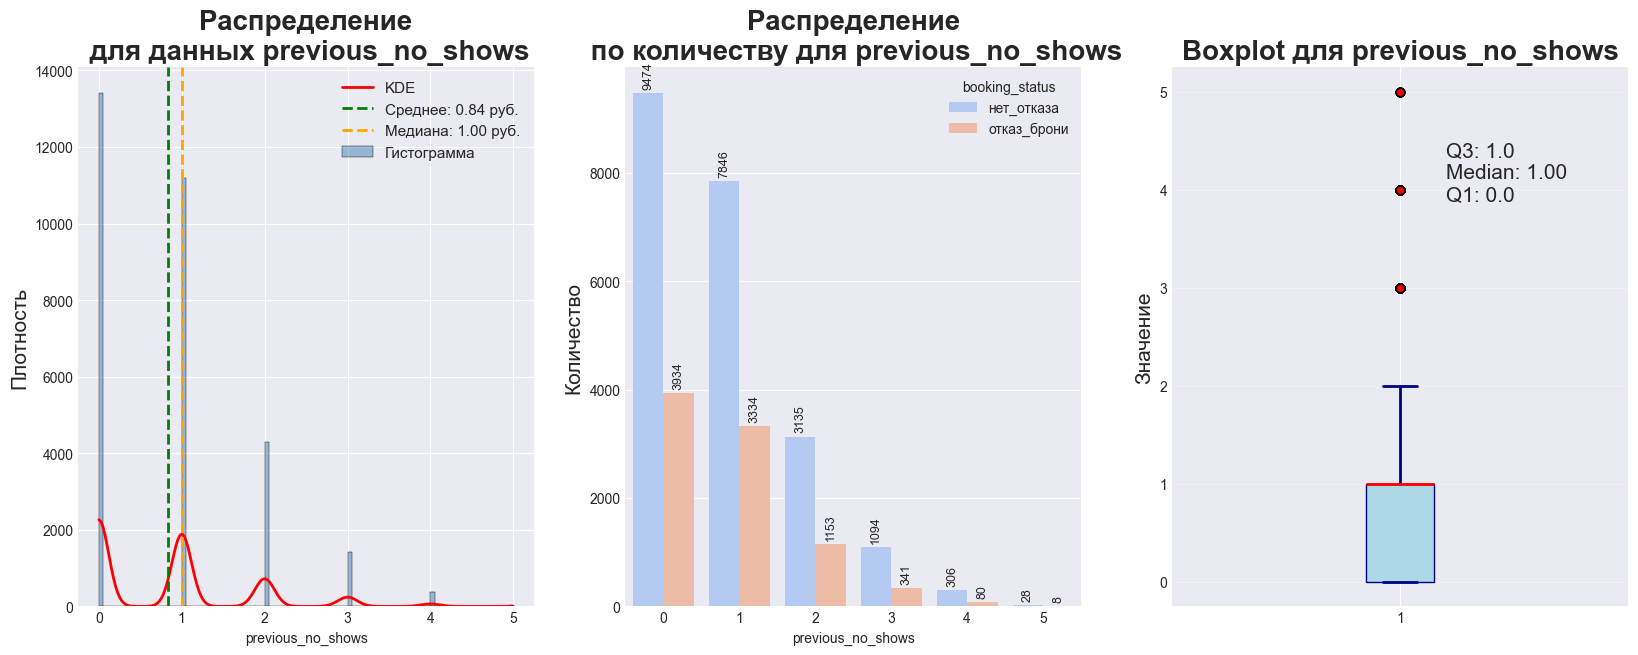

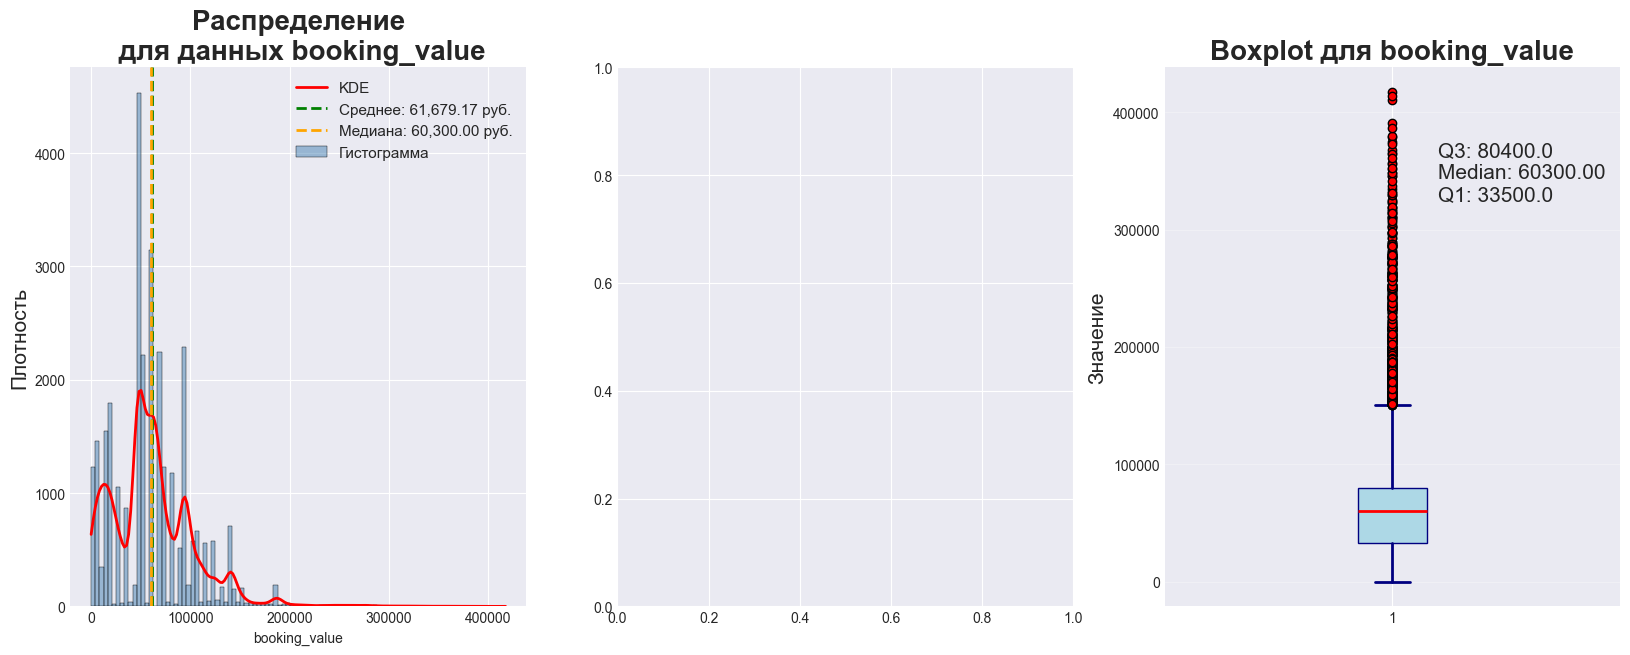

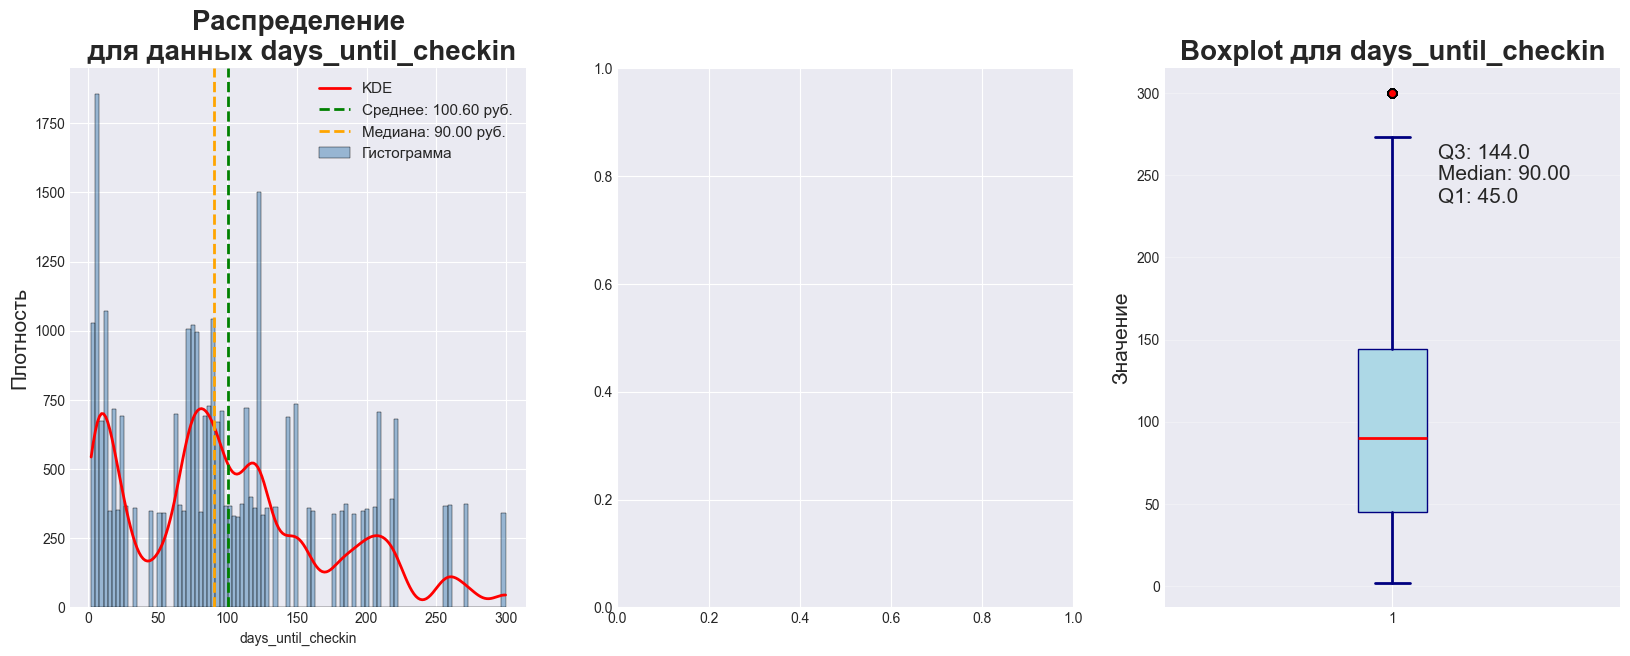

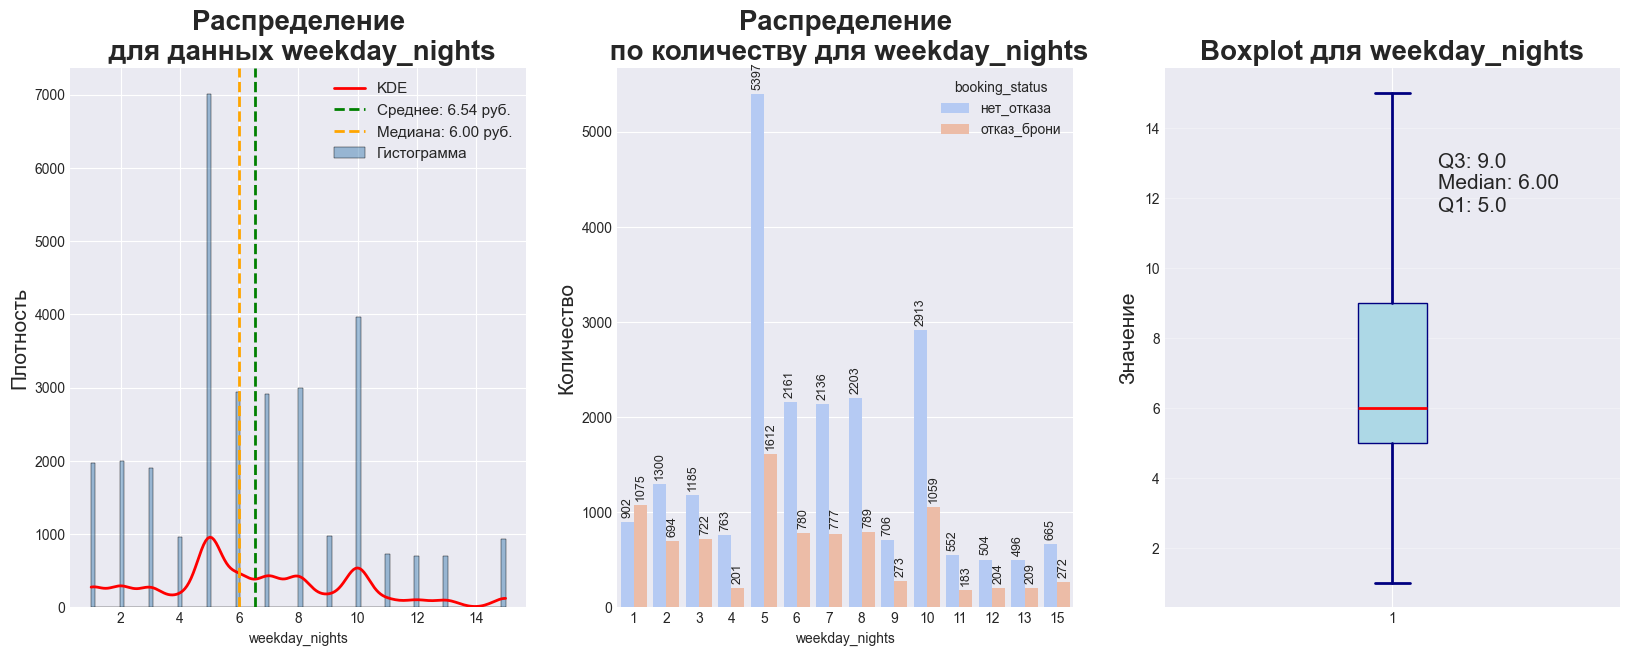

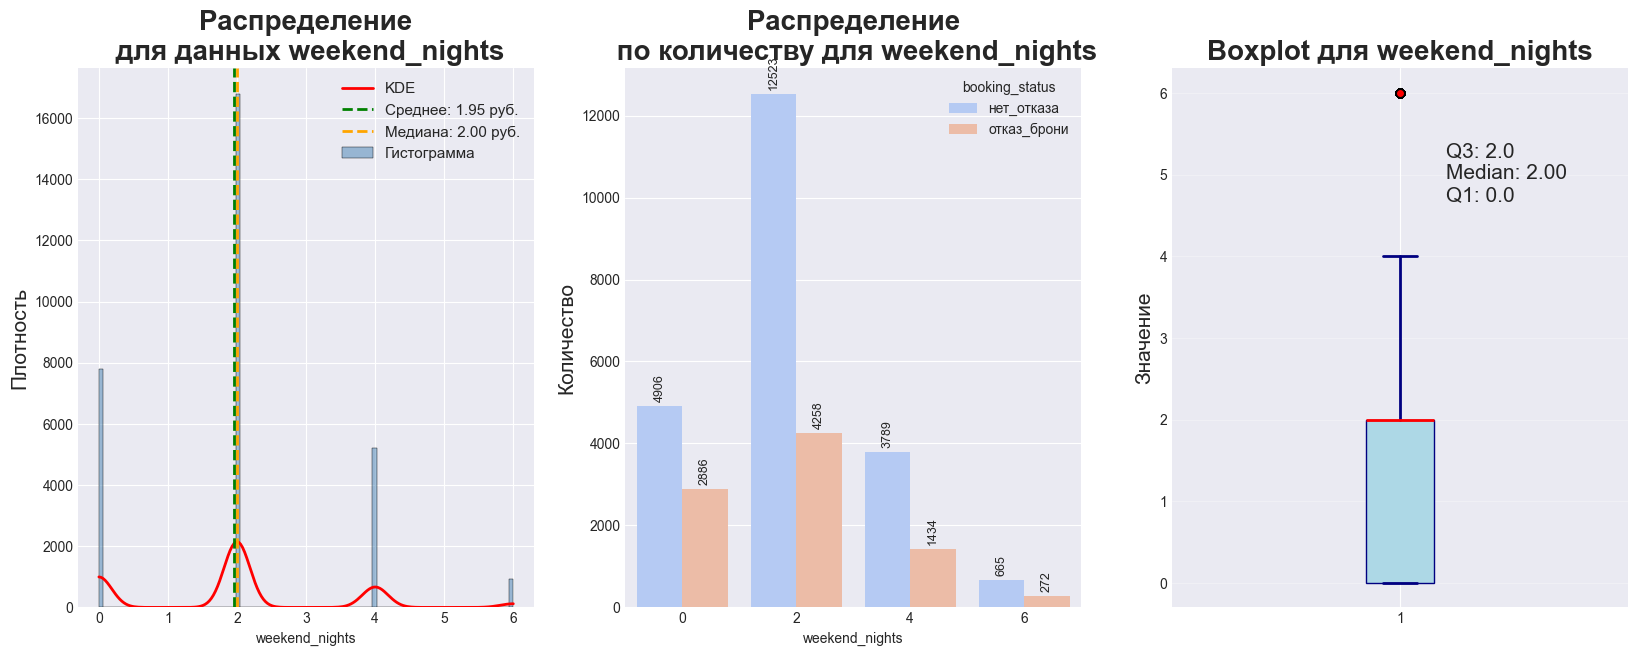

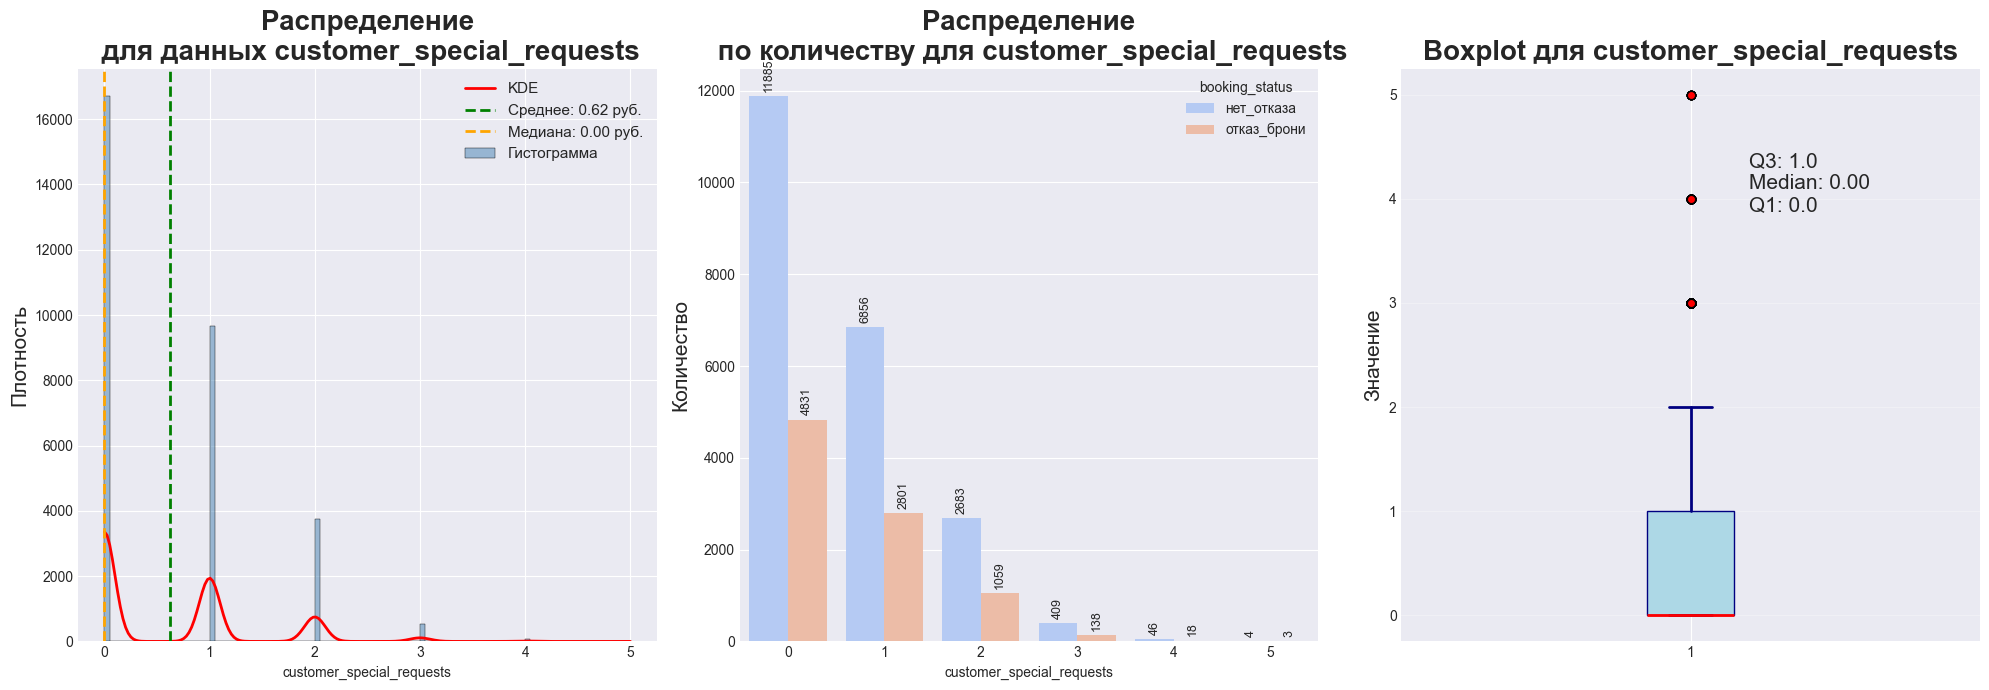

In [18]:
# Выводим графики для датасета df_bookings_drop_dupl
for col in numeric_cols_booking:
    _, axes = plt.subplots(1, 3, figsize=(20, 7))
    print_histplot(df_bookings_drop_dupl, col, axes[0])
    print_countplot(df_bookings_drop_dupl, col, axes[1], 'booking_status', 'coolwarm')
    print_boxplot(df_bookings_drop_dupl, col, axes[2])

plt.tight_layout()
plt.show()

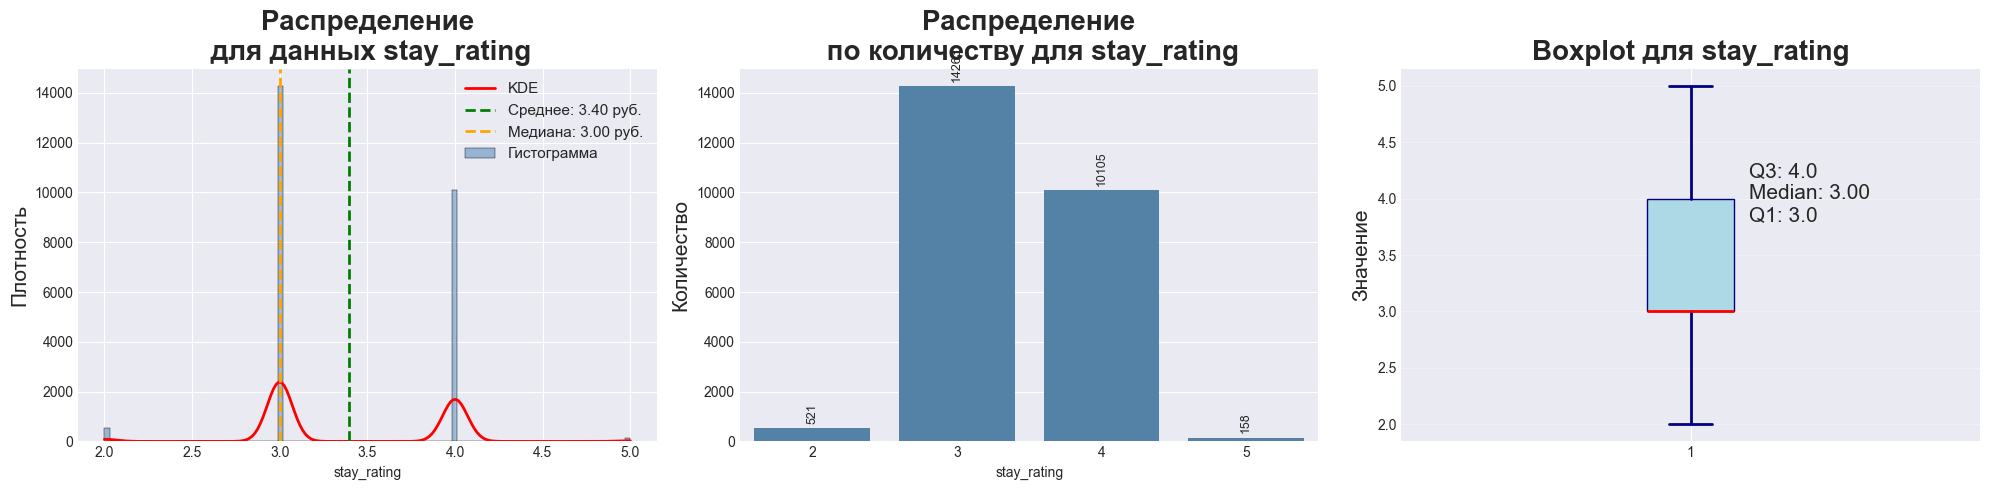

In [19]:
# Выводим графики для датасета df_reviews_drop_dupl
for col in numeric_cols_reviews:
    _, axes = plt.subplots(1, 3, figsize=(20, 5))
    print_histplot(df_reviews_drop_dupl, col, axes[0])
    print_countplot(df_reviews_drop_dupl, col, axes[1])
    print_boxplot(df_reviews_drop_dupl, col, axes[2])

plt.tight_layout()
plt.show()

#### Анализ выбросов

In [20]:
# Функция рассчета выбросов
def mark_iqr_outliers(series): 
    q1 = series.quantile(0.25) 
    q3 = series.quantile(0.75) 
    iqr = q3 - q1 
    lower_bound = q1 - 1.5 * iqr 
    upper_bound = q3 + 1.5 * iqr 
    return ~series.between(lower_bound, upper_bound) 

In [21]:
# Определяем количество выбросов для датасета df_bookings
print('Анализ выбросов для датасета df_bookings\n')
for col in numeric_cols_booking: 
    outliers = mark_iqr_outliers(df_bookings_drop_dupl[col]) 
    print(f"Признак '{col}': найдено {outliers.sum()} выбросов по IQR")

Анализ выбросов для датасета df_bookings

Признак 'adult_count': найдено 2151 выбросов по IQR
Признак 'child_count': найдено 0 выбросов по IQR
Признак 'previous_cancellations': найдено 322 выбросов по IQR
Признак 'previous_no_shows': найдено 1857 выбросов по IQR
Признак 'booking_value': найдено 866 выбросов по IQR
Признак 'days_until_checkin': найдено 340 выбросов по IQR
Признак 'weekday_nights': найдено 0 выбросов по IQR
Признак 'weekend_nights': найдено 937 выбросов по IQR
Признак 'customer_special_requests': найдено 618 выбросов по IQR


In [22]:
# Определяем количество выбросов для датасета df_reviews
print('Анализ выбросов для датасета df_reviews\n')
for col in numeric_cols_reviews: 
    outliers = mark_iqr_outliers(df_reviews_drop_dupl[col]) 
    print(f"Признак '{col}': найдено {outliers.sum()} выбросов по IQR")

Анализ выбросов для датасета df_reviews

Признак 'stay_rating': найдено 0 выбросов по IQR


In [23]:
# Исправляем выбросы
mask = df_bookings_drop_dupl['adult_count'] >= 100
df_bookings_drop_dupl['adult_count'] = df_bookings_drop_dupl['adult_count'].where(~mask, df_bookings_drop_dupl['adult_count'] // 100)

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Верно! Здесь явная ошибка записи. Нужно убрать нули у аномальных значений.</font>

In [24]:
# Удаляем строки с нуливыми ценнами
print(f'Броней с booking_value = 0: {(df_bookings_drop_dupl["booking_value"] == 0).sum()}')
print(f'Строк до очистки: {len(df_bookings_drop_dupl)}')

mask = df_bookings_drop_dupl['booking_value'] == 0
df_bookings_drop_dupl = df_bookings_drop_dupl[~mask]
print(f'Строк после очистки: {len(df_bookings_drop_dupl)}')


Броней с booking_value = 0: 1229
Строк до очистки: 30733
Строк после очистки: 29504


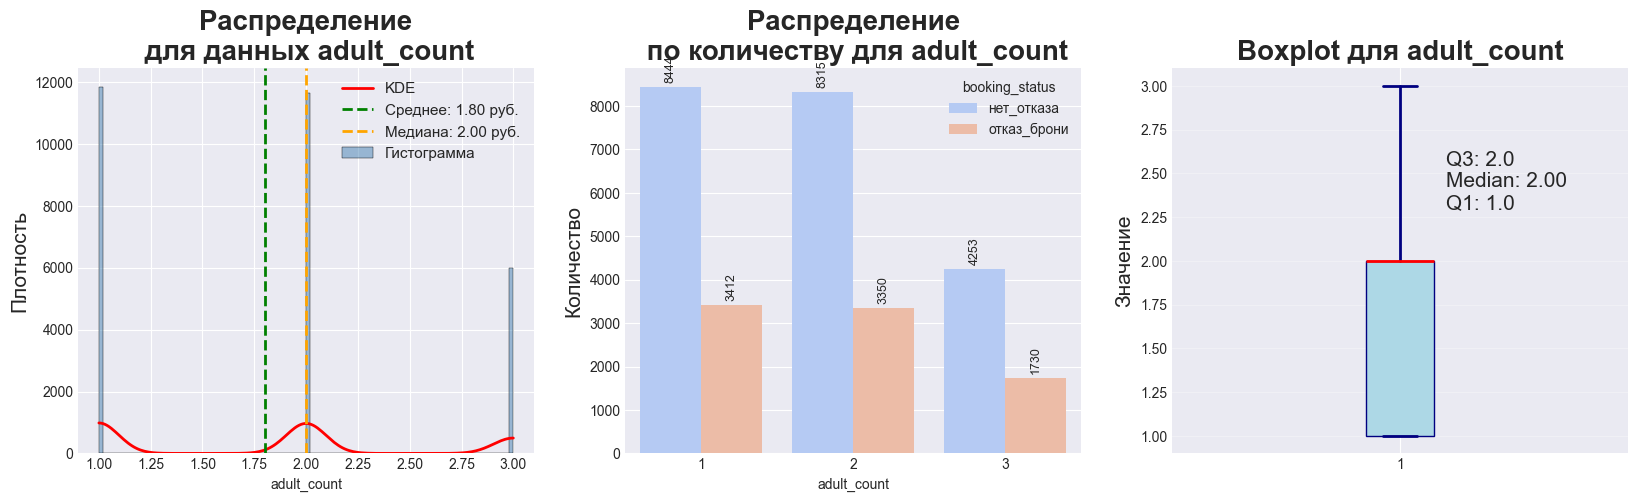

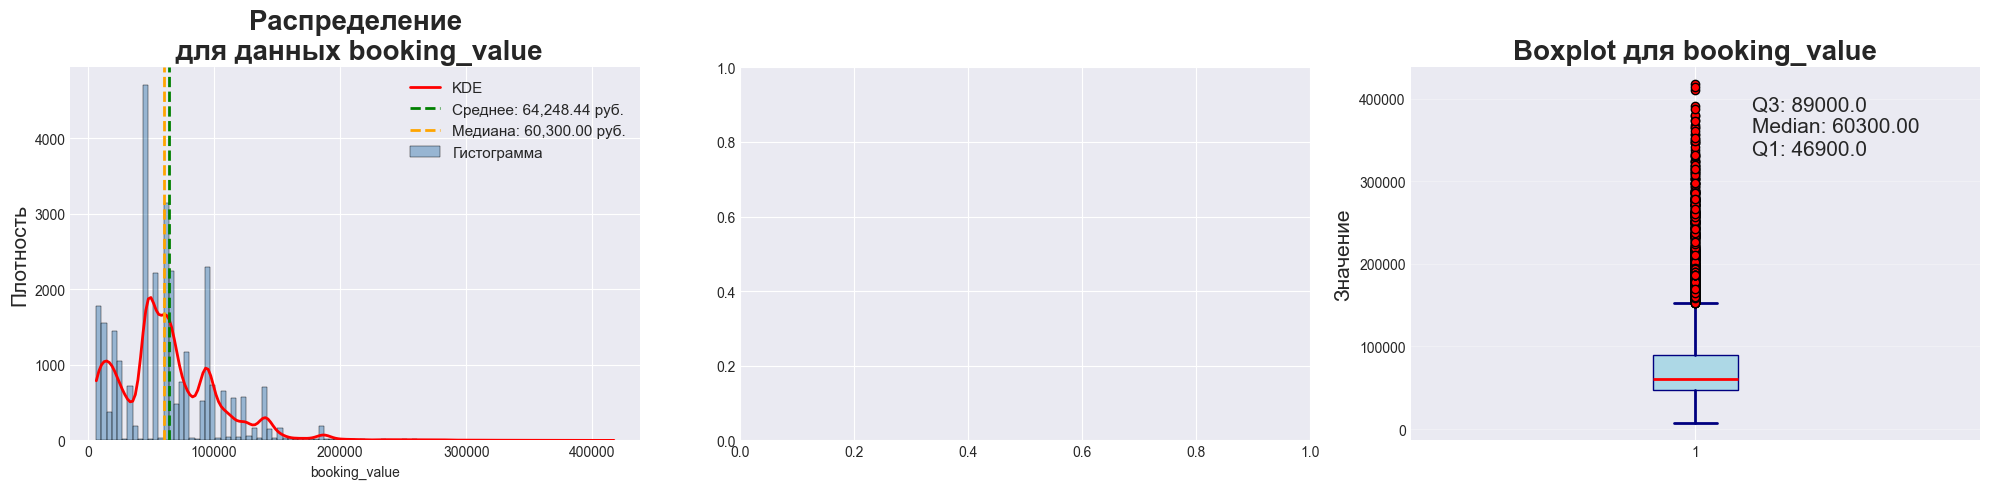

In [25]:
# Выводим графики
for col in ['adult_count', 'booking_value']:
    _, axes = plt.subplots(1, 3, figsize=(20, 5))
    print_histplot(df_bookings_drop_dupl, col, axes[0])
    print_countplot(df_bookings_drop_dupl, col, axes[1], 'booking_status', 'coolwarm')
    print_boxplot(df_bookings_drop_dupl, col, axes[2])

plt.tight_layout()
plt.show()

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>Есть много нулевых значений стоимости.
 Причём и у тех кто отменил бронь, и у тех, кто не отменял.
 В данных не должно так быть. Стоимость номера всегда есть. Поэтому, считаем,
 что данные строки по бронированию не качественные. И лучше от них сразу избавиться.</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Пропустил данную ошибку в данных. Добавил код для удаления строк с нулевыми ценами за бронирование</span>


#### Анализ категориальных и булевых признаков

In [26]:
# Определяем категориальные признаки
category_cols_booking = df_bookings_drop_dupl.select_dtypes(include=['str', 'object', 'bool']).columns.to_list()
category_cols_booking.remove('booking_id')

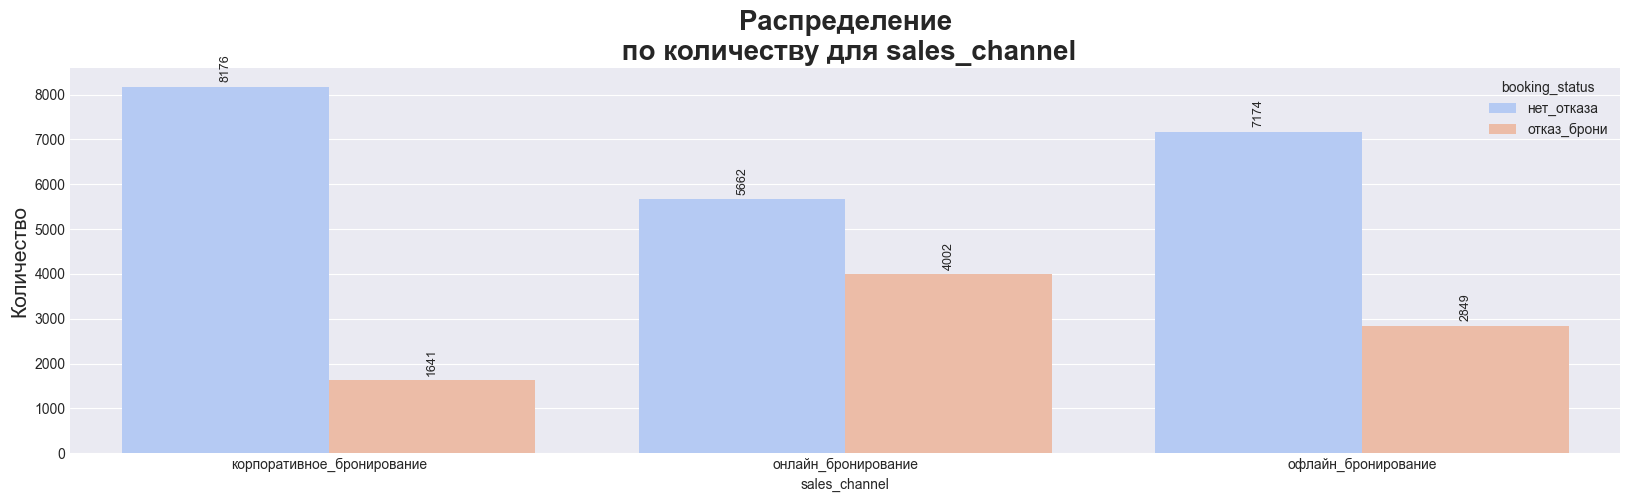

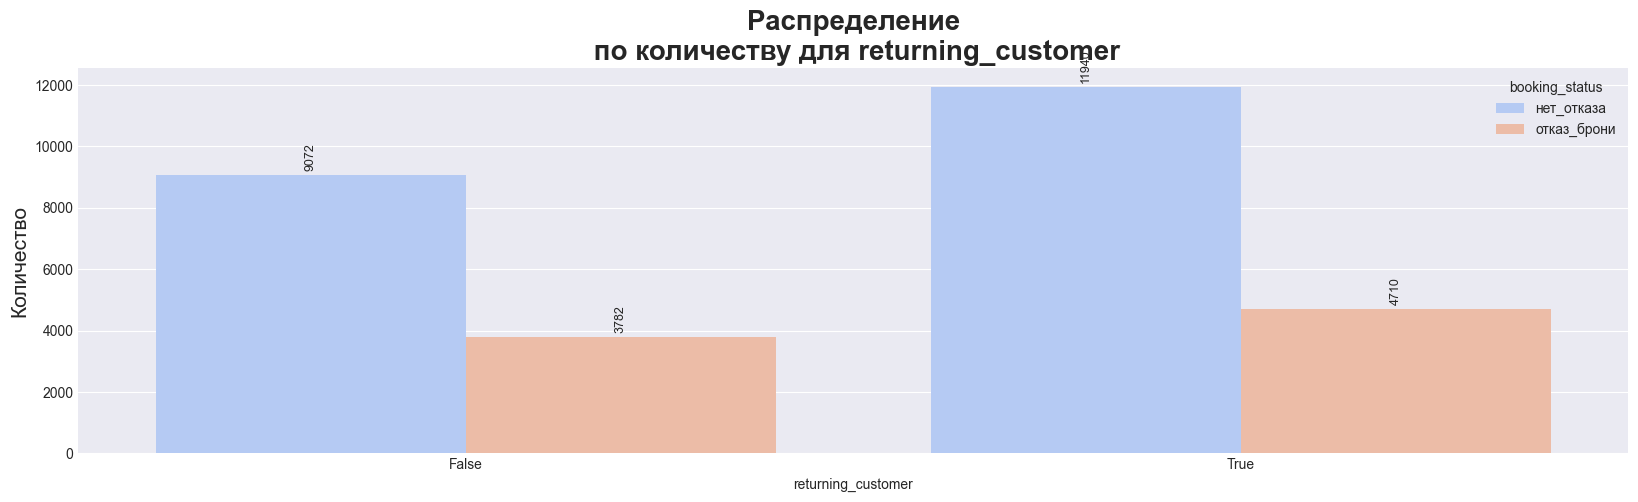

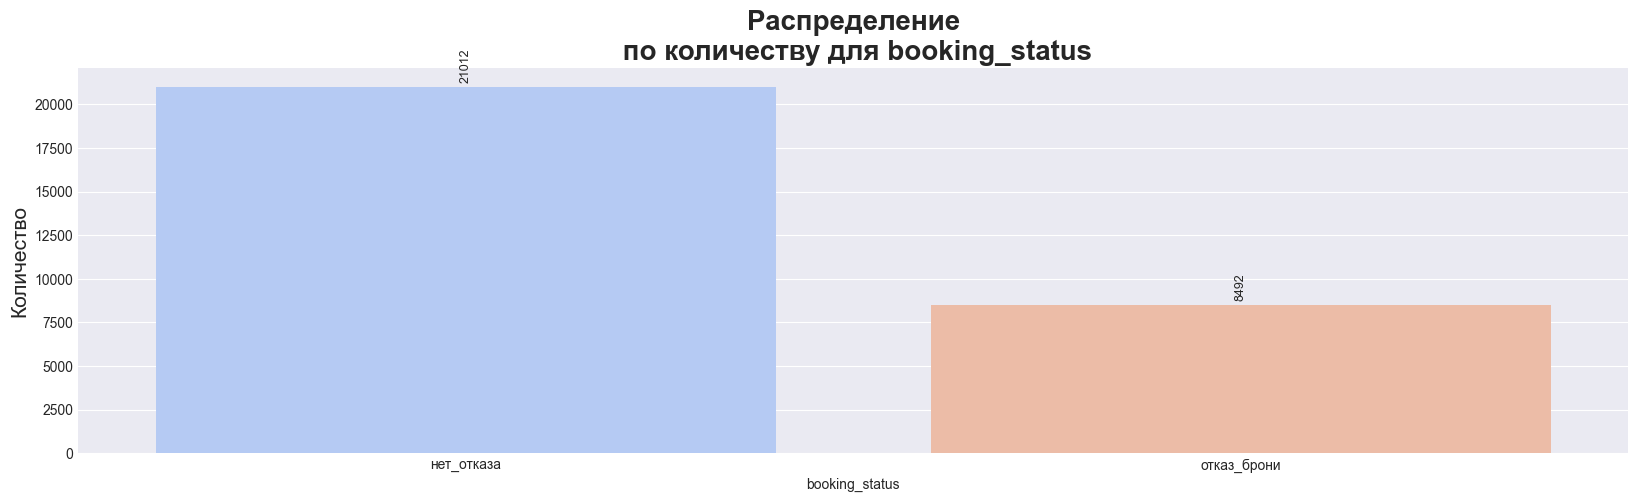

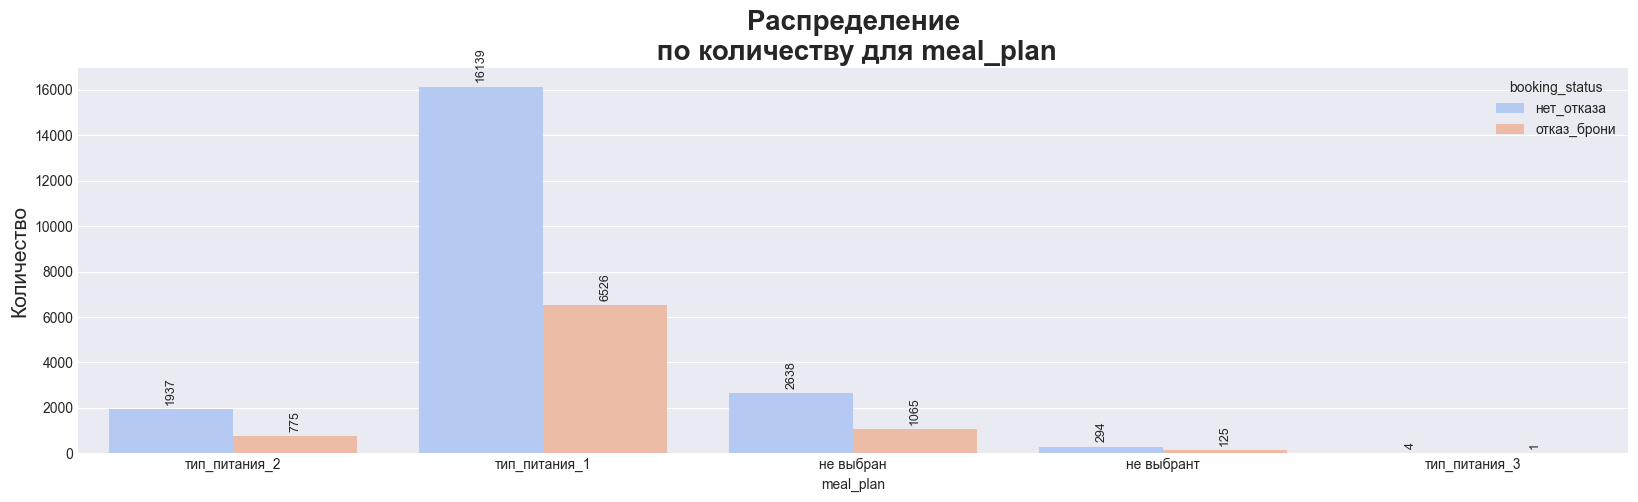

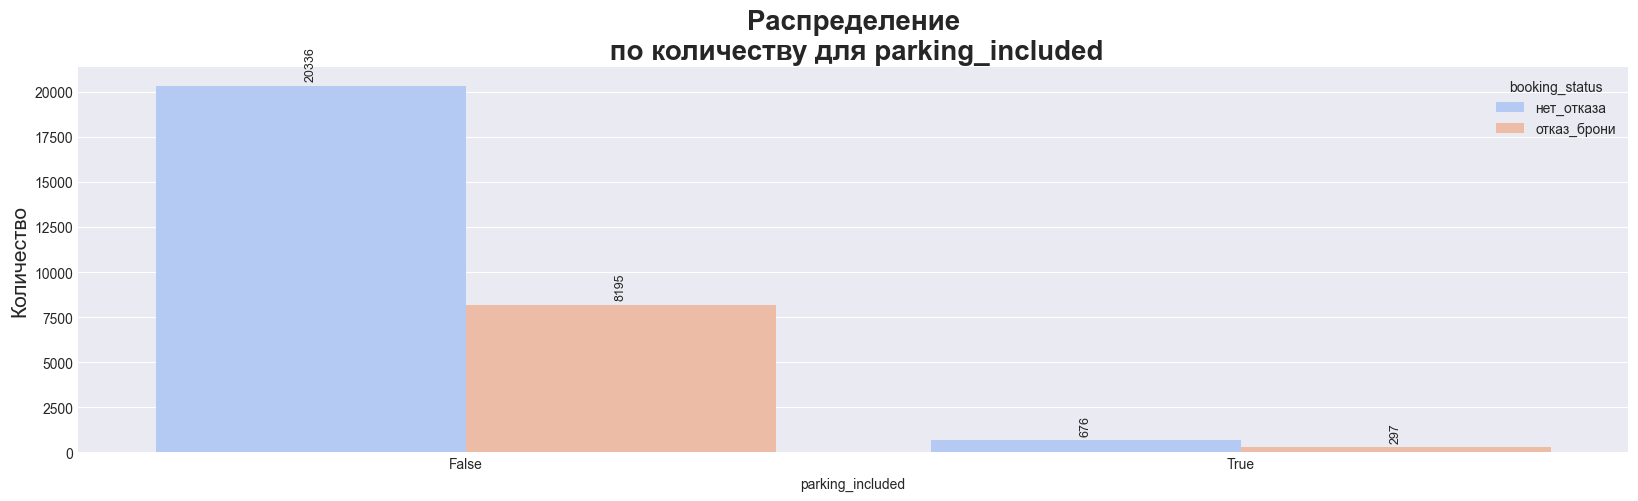

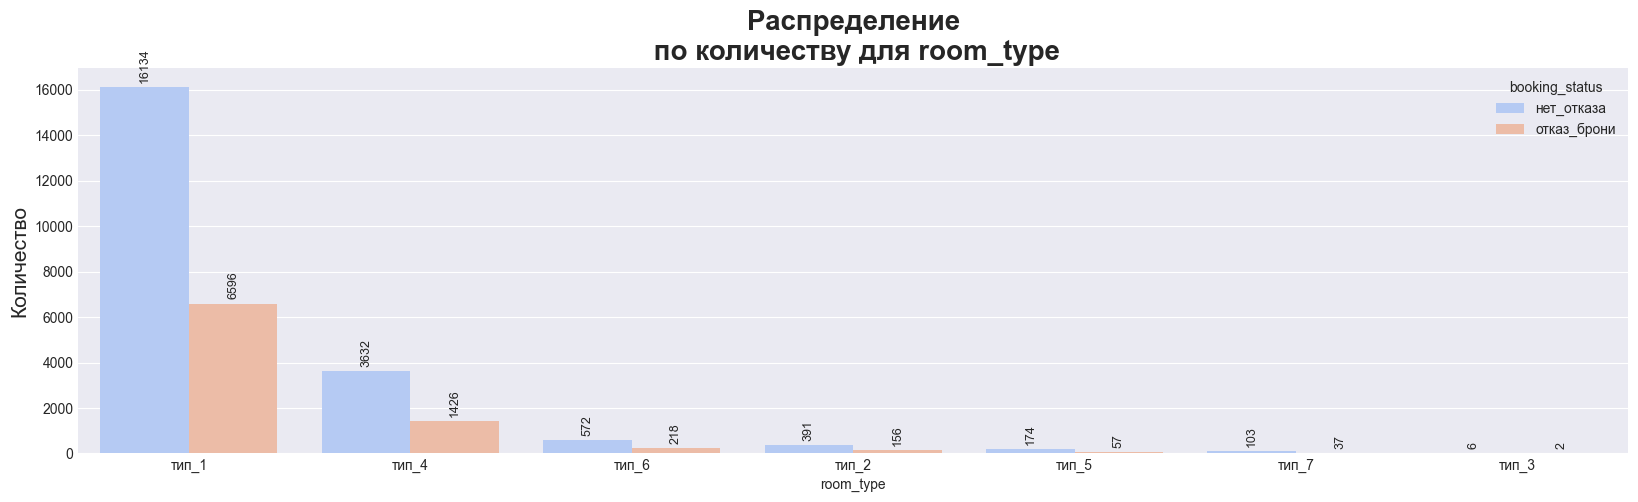

In [27]:
for col in category_cols_booking:
    _, axes = plt.subplots(1, 1, figsize=(20, 5))
    print_countplot(df_bookings_drop_dupl, col, axes, 'booking_status', 'coolwarm')

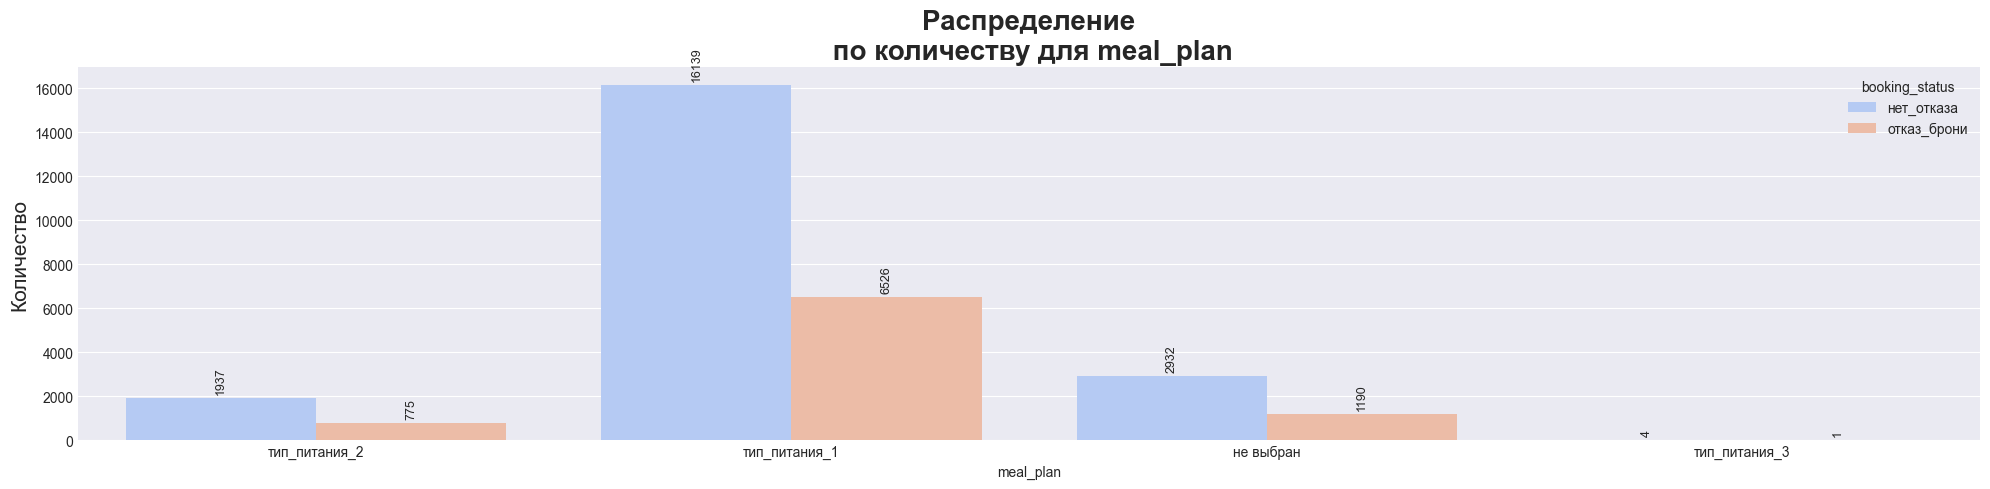

In [28]:
# Исправляем опечатки в признаке 'meal_plan'
df_bookings_drop_dupl['meal_plan'] = df_bookings_drop_dupl['meal_plan'].replace('не выбрант', 'не выбран')

# Выводим графики
_, axes = plt.subplots(1, 1, figsize=(20, 5))
print_countplot(df_bookings_drop_dupl, 'meal_plan', axes, 'booking_status', 'coolwarm')

plt.tight_layout()
plt.show()


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Отлично, поправили опечатку!</font>

#### Анализ признаков с датами

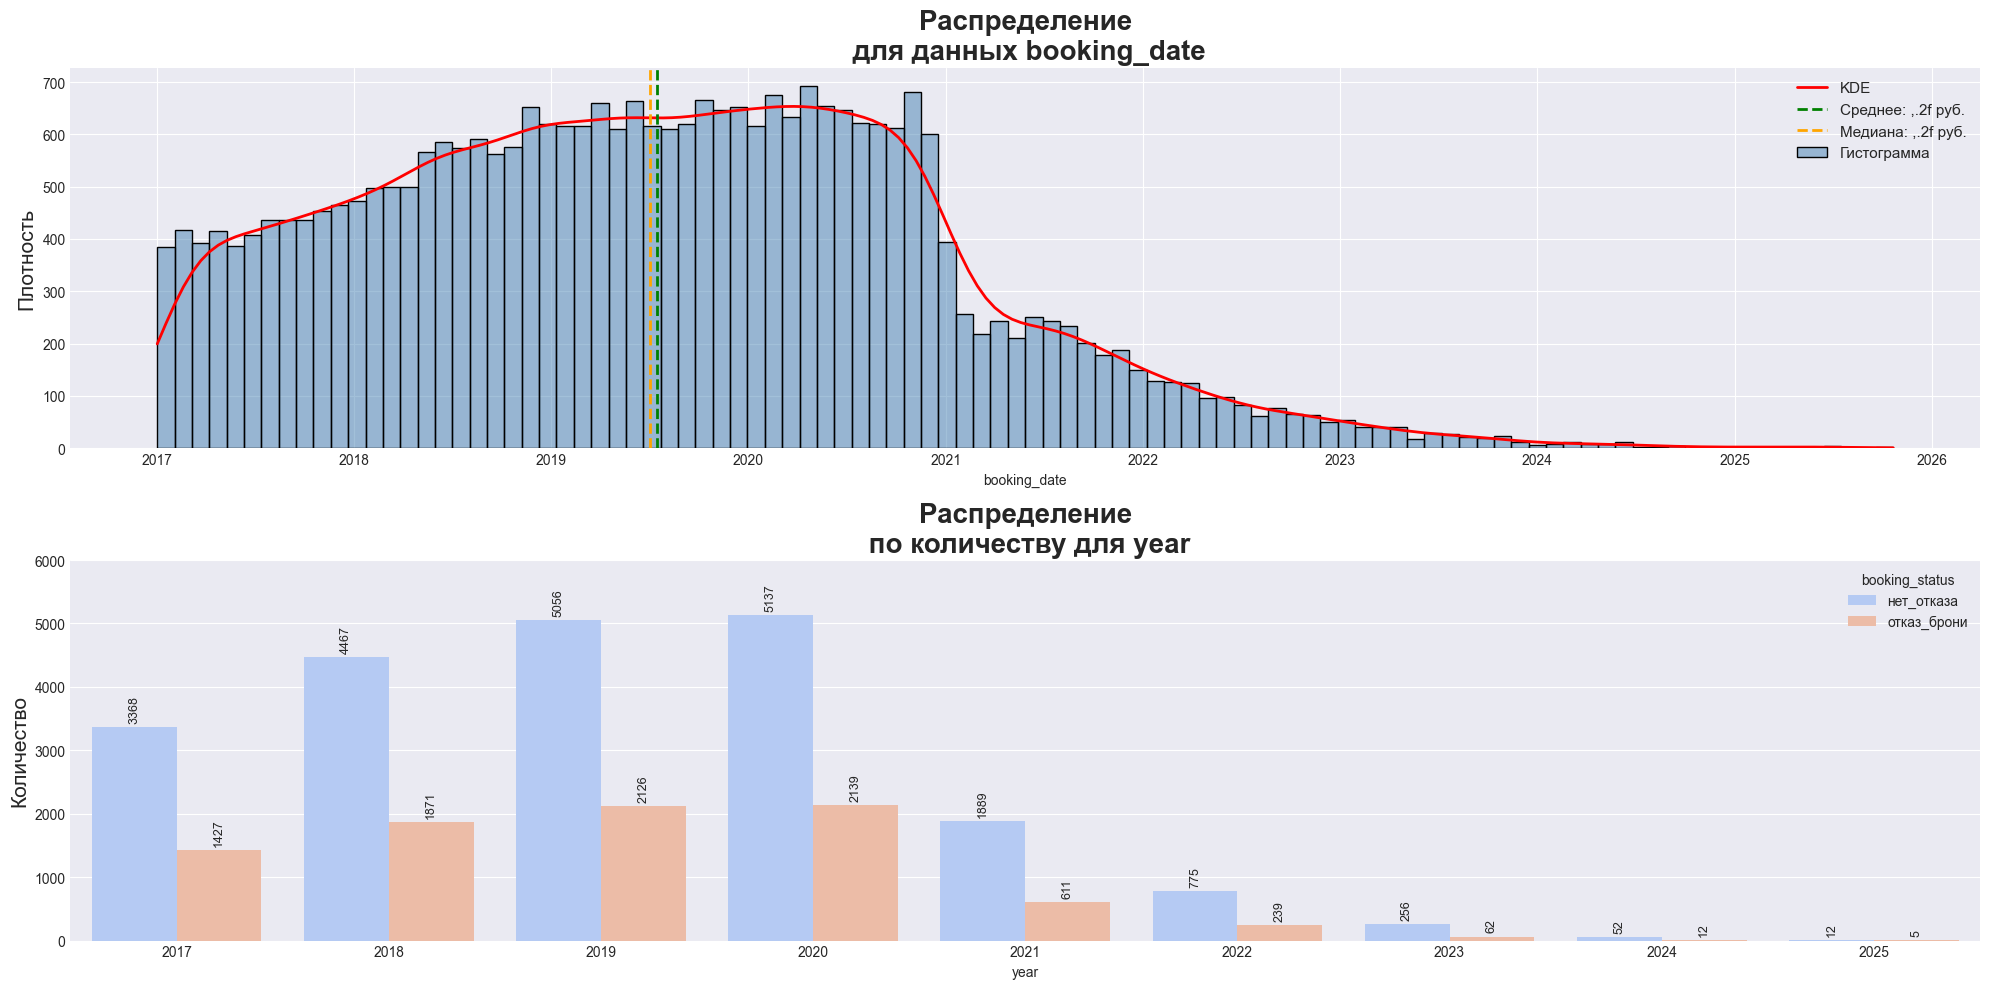

In [29]:
# Выделим из даты год 
df_bookings_date = df_bookings_drop_dupl.copy()
df_bookings_date['year'] = df_bookings_date['booking_date'].dt.strftime('%Y')

# Выводим графики
_, axes = plt.subplots(2, 1, figsize=(20, 10), gridspec_kw={'height_ratios': [1, 1]})
print_histplot(df_bookings_date, 'booking_date', axes[0])
print_countplot(df_bookings_date.sort_values('year'), 'year', axes[1], 'booking_status', 'coolwarm')

axes[1].set_ylim(0, axes[1].get_yticks().max()) 
plt.tight_layout()

#### Анализ корреляционной матрицы

d:\ProjectPython\Sprint17_Booking_Cancellation_Predict\.ml_env_sprint17\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable booking_date is large: 2440. Are you sure this is not an interval variable? Analysis for pairs of variables including booking_date can be slow.
  warnings.warn(


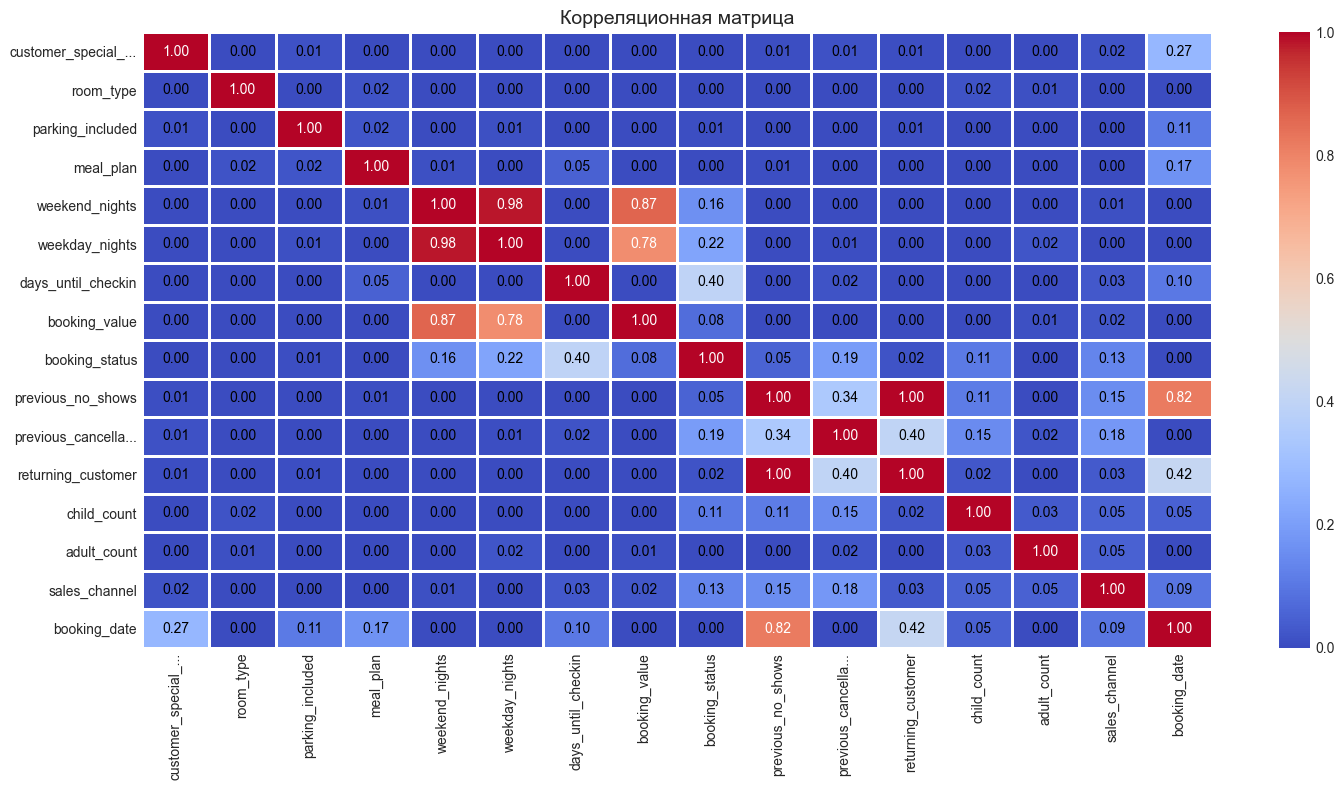

In [30]:
# Удаляем уникальный номер брони
matrix_df = df_bookings_drop_dupl.drop(columns=['booking_id'])

# Рассчитываем матрицу для всех признаков
phik_matrix = matrix_df.phik_matrix(interval_cols=['booking_value'])

# Визуализация матрицы
plot_correlation_matrix(
    phik_matrix.values,
    x_labels=phik_matrix.columns,
    y_labels=phik_matrix.index,
    vmin=0, vmax=1,
    title='Корреляционная матрица',
    figsize=(15, 8),
    color_map='coolwarm'
)

plt.show()

#### Промежуточный вывод по загрузке и предобработка данных

**1. Загрузка данных**

Из базы данных PostgreSQL выгружены две таблицы: `hotel_bookings` (35 341 бронь) и `hotel_reviews` (25 177 отзывов). Пропусков в исходных данных не обнаружено; типы признаков приведены к корректным (даты `booking_date` и `review_date` переведены в `datetime`).

**2. EDA и предобработка**

- Выявлены и удалены явные дубликаты: 4 608 строк в `hotel_bookings` (по `booking_id`) и 130 в `hotel_reviews` (по `customer_id`, `booking_id`, `review_date`). После очистки осталось 30 733 уникальные брони.
- Проанализированы распределения числовых, категориальных и временных признаков (гистограммы с KDE, countplot'ы в разрезе `booking_status`, boxplot'ы). Доля отменённых броней составляет около 29%, что задаёт умеренную несбалансированность классов для задачи классификации.
- По методу IQR выбросы обнаружены в 7 из 9 числовых признаков. Аномалия в `adult_count` (значения ≥ 100) исправлена делением на 100 — это явная ошибка записи.
- Удалены строки с нулевой стоимостью бронирования (`booking_value = 0`): стоимость номера не может быть нулевой, такие записи считаются некачественными. После удаления осталось **29504** броней.
- Исправлена опечатка в признаке `meal_plan` (`не выбрант` → `не выбран`).
- Проанализирована динамика броней во времени: выделен год бронирования, заметны колебания объёма бронирований по годам в разрезе отмен.
- Построена корреляционная матрица на основе φ-k (phik), учитывающая как линейные, так и нелинейные зависимости. Наиболее выраженная связь с отменой брони прослеживается у таких признаков, как срок до заезда (`days_until_checkin`), история клиента (`previous_cancellations`, `previous_no_shows`) и канал продаж (`sales_channel`).

**3. Итог блока**

Данные очищены от дубликатов и некачественных записей, аномалии устранены, опечатки исправлены. Таблица `df_bookings_drop_dupl` готова к следующему шагу — объединению с данными отзывов и созданию новых признаков.

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'>Здорово,что применена `phik` для анализа и нелинейных зависимостей</font>

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'>Здесь заканчивается структурный блок работы - стоит сделать промежуточные выводы о проделанной работе в блоке.</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Добавил промежуточный вывод по итогам загрузки и предобработка данных.</span>

### [1.4 Объединение таблиц <a id=1_4></a>](#content)

In [31]:
# Добавляем customer_id в бронирования
customer_map = df_reviews_drop_dupl[['booking_id', 'customer_id']].drop_duplicates().set_index('booking_id')['customer_id']
df_bookings_drop_dupl['customer_id'] = df_bookings_drop_dupl['booking_id'].map(customer_map)

# Разделяем: те, у кого есть customer_id (для слияния) и те, у кого нет (оставляем как есть)
has_customer = df_bookings_drop_dupl['customer_id'].notna()
df_bookings_with_customer = df_bookings_drop_dupl[has_customer].copy()
df_bookings_without_customer = df_bookings_drop_dupl[~has_customer].copy()

# Сортируем для merge_asof
df_bookings_sorted = df_bookings_with_customer.sort_values(
    ['booking_date', 'customer_id'], ascending=[True, True]
).reset_index(drop=True)

df_reviews_sorted = df_reviews_drop_dupl.sort_values(
    ['review_date', 'customer_id'], ascending=[True, True]
).reset_index(drop=True)

# Выполняем слияние
merged = pd.merge_asof(
    df_bookings_sorted,
    df_reviews_sorted[['customer_id', 'review_date', 'stay_rating', 'review_text']],
    left_on='booking_date',
    right_on='review_date',
    by='customer_id',
    direction='backward',
    allow_exact_matches=False
)

# Объединяем с теми записями, у которых не было customer_id (у них добавленные колонки будут NaN)
df_merge_booking = pd.concat([merged, df_bookings_without_customer], ignore_index=True)

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Отлично, что применяется pd.merge_asof</font>

In [32]:
# Выводим общую информацию об объеденненой таблице
primary_info(df_merge_booking, 'df_merge_bookings')

Информация о таблице: df_merge_bookings


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,review_date,stay_rating,review_text
0,INN21754,2017-01-01,онлайн_бронирование,3,2,False,0,0,нет_отказа,67 000.000,124,8,2,тип_питания_2,False,тип_2,0,C11662,NaT,NaN,NaN
1,INN22445,2017-01-01,офлайн_бронирование,2,0,False,0,0,нет_отказа,71 200.000,85,6,2,не выбран,False,тип_1,0,C12041,NaT,NaN,NaN
2,INN11824,2017-01-01,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6 700.000,63,1,0,тип_питания_1,False,тип_4,1,C6306,NaT,NaN,NaN
3,INN14477,2017-01-01,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46 900.000,85,5,2,тип_питания_1,True,тип_1,2,C7722,NaT,NaN,NaN
4,INN17387,2017-01-01,офлайн_бронирование,2,0,True,1,1,нет_отказа,73 700.000,79,9,2,тип_питания_1,False,тип_1,2,C9324,NaT,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype        
---  ------                     --------------  -----        
 0   booking_id                 29504 non-null  str          
 1   booking_date               29504 non-null  datetime64[s]
 2   sales_channel              29504 non-null  str          
 3   adult_count                29504 non-null  int64        
 4   child_count                29504 non-null  int64        
 5   returning_customer         29504 non-null  bool         
 6   previous_cancellations     29504 non-null  int64        
 7   previous_no_shows          29504 non-null  int64        
 8   booking_status             29504 non-null  str          
 9   booking_value              29504 non-null  float64      
 10  days_until_checkin         29504 non-null  int64        
 11  weekday_nights             29504 non-null  int64        
 12  weekend_nights             29

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
booking_id,29504,29504,INN21754,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_date,29504,NaN,NaN,NaN,2019-07-15 14:03:02,2017-01-01 00:00:00,2018-06-11 00:00:00,2019-07-03 00:00:00,2020-07-07 00:00:00,2025-10-22 00:00:00,NaN
sales_channel,29504,3,офлайн_бронирование,10023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_count,29 504.000,NaN,NaN,NaN,1.801,1.000,1.000,2.000,2.000,3.000,0.752
child_count,29 504.000,NaN,NaN,NaN,0.357,0.000,0.000,0.000,1.000,2.000,0.585
returning_customer,29504,2,True,16650,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous_cancellations,29 504.000,NaN,NaN,NaN,0.358,0.000,0.000,0.000,1.000,5.000,0.629
previous_no_shows,29 504.000,NaN,NaN,NaN,0.841,0.000,0.000,1.000,1.000,5.000,0.933
booking_status,29504,2,нет_отказа,21012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_value,29 504.000,NaN,NaN,NaN,64 248.437,6 700.000,46 900.000,60 300.000,89 000.000,417 221.200,41 683.137


**Промежуточный вывод**

- К бронированиям добавлен `customer_id`: он найден для 21 883 записей через сопоставление по `booking_id` из таблицы отзывов.
- С помощью `pd.merge_asof` (direction='backward', allow_exact_matches=False) к каждой брони подтянут последний по времени **предыдущий** отзыв того же клиента — такой подход корректно использует историю клиента без «заглядывания в будущее».
- Отзывные признаки (`stay_rating`, `review_date`, `review_text`) получили 8 328 броней; у остальных записей они отсутствуют (`NaN`) — у клиента нет предыдущих отзывов.
- Итоговая таблица `df_merge_booking` содержит 29504 строк и 21 колонку. Пропуски сосредоточены только в отзывных признаках, целевая переменная `booking_status` сохранена.

<font color='blue'><b>Комментарий ревьюера : </b></font> ❌\
<font color='red'>Вывод.  </font> 

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Добавил краткий вывод.</span>


### [1.5 Создание новых признаков <a id=1_5></a>](#content)

In [33]:
# Объявляем множество из стоп-слов русского языка
russian_stopwords = set(stopwords.words('russian'))

# Создаем базовую токенизацию
_word_re = re.compile(r'[а-яё]+', re.IGNORECASE)

# Объявляем функцию для токенизации текста
def tokenize_ru(text):
    return _word_re.findall(str(text).lower())

# Объявляем функцию для удаления стоп-слов
def remove_stopwords(text):
    return " ".join([word for word in text if word not in russian_stopwords])

In [34]:
def add_booking_features(df):
    """
    Создаем дополнительные признаки для датафрейма
    """
    df = df.copy()

    # Состав гостей 
    df['total_guests'] = df['adult_count'] + df['child_count']
    guests_safe = df['total_guests'].clip(lower=1)
    df['children_share'] = df['child_count'] / guests_safe
    df['adults_share'] = df['adult_count'] / guests_safe
    df['has_adults'] = (df['adult_count'] > 0).astype(int)
    df['has_children'] = (df['child_count'] > 0).astype(int)
    df['is_large_group'] = (df['total_guests'] >= 4).astype(int)

    # Длительность проживания
    df['total_nights'] = df['weekday_nights'] + df['weekend_nights']
    nights_safe = df['total_nights'].replace(0, 1)  # защита от нуля

    df['weekend_share'] = df['weekend_nights'] / nights_safe
    df['is_long_stay'] = (df['total_nights'] >= 7).astype(int)

    bins_stay = [-1, 1, 3, 6, 1000]
    labels_stay = ['single_night', 'short', 'medium', 'long']
    df['stay_length_bucket'] = pd.cut(
        df['total_nights'], bins=bins_stay, labels=labels_stay, right=True
    )

    # Стоимость    
    df['avg_price_per_night'] = df['booking_value'] / nights_safe
    df['price_per_guest'] = df['booking_value'] / guests_safe
    df['price_per_guest_per_night'] = df['booking_value'] / (guests_safe * nights_safe)  

    premium_threshold = df['booking_value'].quantile(0.75)
    df['is_premium'] = (df['booking_value'] >= premium_threshold).astype(int)
    df['log_price'] = np.log1p(df['booking_value'])

    # Календарь: дата заезда
    df['checkin_date'] = pd.to_datetime(df['booking_date']) + pd.to_timedelta(
        df['days_until_checkin'], unit='D'
    )

    # Категоризация дней до заезда
    bins = [-1, 7, 30, 90, 1000]
    labels = ['very_soon', 'soon', 'medium', 'long_ahead']
    df['days_until_checkin_bucket'] = pd.cut(
        df['days_until_checkin'], bins=bins, labels=labels, right=True
    )

    # Сервисы и канал
    df['has_meal_plan'] = (df['meal_plan'] != 'не выбран').astype(int)
    df['has_special_request'] = (df['customer_special_requests'] > 0).astype(int)
    df['request_density'] = df['customer_special_requests'] / nights_safe
    df['service_level'] = (
        df['parking_included'].astype(int)
        + df['has_meal_plan']
        + df['has_special_request']
    )

    # История клиента (из готовых признаков)
    df['total_issues'] = df['previous_cancellations'] + df['previous_no_shows']
    df['has_cancelled_before'] = (df['previous_cancellations'] > 0).astype(int)
    df['has_no_show_before'] = (df['previous_no_shows'] > 0).astype(int)
    df['issues_rate'] = df['total_issues'] / (df['total_issues'] + 1)

    # Отзывы (прошлый отзыв клиента)
    df['has_review'] = df['stay_rating'].notna().astype(int)

    review_gap = (
        pd.to_datetime(df['booking_date']) - pd.to_datetime(df['review_date'])
    ).dt.days
    df['days_since_review'] = review_gap.clip(lower=0).fillna(-1)

    df['rating_bucket'] = pd.cut(
        df['stay_rating'],
        bins=[0, 2.5, 3.5, 5.5],
        labels=['low', 'mid', 'high']
    )
    df['rating_bucket'] = df['rating_bucket'].astype('object').fillna('no_review')

    # Взаимодействия
    df['prev_cancel_x_noshow'] = (
        df['previous_cancellations'] * df['previous_no_shows']
    )
    df['returning_x_cancels'] = (
        df['returning_customer'].astype(int) * df['previous_cancellations']
    )
    df['guests_x_weekend'] = df['total_guests'] * df['weekend_share']
    df['requests_x_parking'] = (
        df['customer_special_requests'] * df['parking_included'].astype(int)
    )

    return df

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> 👍</font>

In [35]:
def add_booking_features_old(df):
    """
    Создаем дополнительные признаки для датафрейма
    """
    df = df.copy()

    # Общая длительность прибывания
    df['total_nights'] = df['weekday_nights'] + df['weekend_nights']

    # Стоимость одной ночи за гостя
    guests_count = df['adult_count'] + df['child_count'] + 1 # защита от нуля и появления ошибки ZeroDivisionError
    nights_count = df['total_nights'].replace(0, 1) # временная замена для расчета
    df['price_per_guest_per_night'] = df['booking_value'] / (guests_count * nights_count)

    # Категоризация дней до заезда
    bins = [-1, 7, 30, 90, 1000]
    labels = ['very_soon', 'soon', 'medium', 'long_ahead']
    df['days_until_checkin_bucket'] = pd.cut(
        df['days_until_checkin'],
        bins=bins,
        labels=labels,
        right=True
    )

    return df

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> 👍</font>

In [36]:
def feature_extraction_text(df):
    """
    Функция токенезирует признак с отзывами
    """
    df = df.copy()

    # Заполняем пропуски пустой строкой, чтобы TF-IDF не падал
    texts = df['review_text'].fillna('').astype(str)

    processed_texts = []
    for text in texts:
        tokens = tokenize_ru(text)
        filtered_tokens = remove_stopwords(tokens)
        processed_texts.append(filtered_tokens)

    vectorizer = TfidfVectorizer(
        max_features=50,
        ngram_range=(1, 2)
    )

    tfidf_matrix = vectorizer.fit_transform(processed_texts)

    # Превращаем в DataFrame с понятными именами колонок
    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=[f'review_tfidf_{i}' for i in range(tfidf_matrix.shape[1])],
        index=df.index
    )

    return pd.concat([df.drop(columns=['review_text']), tfidf_df], axis=1)

In [37]:
def extract_time_features(df):
    """Функция для извлечения новых признаков из datetime"""
    df = df.copy()
    
    for col in df.select_dtypes(include='datetime').columns.to_list():
        # Если дата пропущена, заполняем дефолтной эпохой, чтобы .dt работал без ошибок
        temp_date = df[col].fillna(pd.Timestamp('1970-01-01'))
        
        df[f'{col}_year'] = temp_date.dt.year
        df[f'{col}_month'] = temp_date.dt.month
        df[f'{col}_day_of_week'] = temp_date.dt.dayofweek 
        
        # Циклические признаки для месяца
        df[f'{col}_month_sin'] = np.sin(2 * np.pi * df[f'{col}_month'] / 12)
        df[f'{col}_month_cos'] = np.cos(2 * np.pi * df[f'{col}_month'] / 12)
        
        # Удаляем исходный признак
        df.drop([col], axis=1, inplace=True)

    return df

In [38]:
# Создаем новые признаки и токенизацию отзывов
df_merge_booking_with_features = add_booking_features(df_merge_booking)
df_merge_booking_with_features = extract_time_features(df_merge_booking_with_features)
df_merge_booking_with_features = feature_extraction_text(df_merge_booking_with_features)
df_merge_booking_with_features

,booking_id,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,stay_rating,total_guests,children_share,adults_share,has_adults,has_children,is_large_group,total_nights,weekend_share,is_long_stay,stay_length_bucket,avg_price_per_night,price_per_guest,price_per_guest_per_night,is_premium,log_price,days_until_checkin_bucket,has_meal_plan,has_special_request,request_density,service_level,total_issues,has_cancelled_before,has_no_show_before,issues_rate,has_review,days_since_review,rating_bucket,prev_cancel_x_noshow,returning_x_cancels,guests_x_weekend,requests_x_parking,booking_date_year,booking_date_month,booking_date_day_of_week,booking_date_month_sin,booking_date_month_cos,review_date_year,review_date_month,review_date_day_of_week,review_date_month_sin,review_date_month_cos,checkin_date_year,checkin_date_month,checkin_date_day_of_week,checkin_date_month_sin,checkin_date_month_cos,review_tfidf_0,review_tfidf_1,review_tfidf_2,review_tfidf_3,review_tfidf_4,review_tfidf_5,review_tfidf_6,review_tfidf_7,review_tfidf_8,review_tfidf_9,review_tfidf_10,review_tfidf_11,review_tfidf_12,review_tfidf_13,review_tfidf_14,review_tfidf_15,review_tfidf_16,review_tfidf_17,review_tfidf_18,review_tfidf_19,review_tfidf_20,review_tfidf_21,review_tfidf_22,review_tfidf_23,review_tfidf_24,review_tfidf_25,review_tfidf_26,review_tfidf_27,review_tfidf_28,review_tfidf_29,review_tfidf_30,review_tfidf_31,review_tfidf_32,review_tfidf_33,review_tfidf_34,review_tfidf_35,review_tfidf_36,review_tfidf_37,review_tfidf_38,review_tfidf_39,review_tfidf_40,review_tfidf_41,review_tfidf_42,review_tfidf_43,review_tfidf_44,review_tfidf_45,review_tfidf_46,review_tfidf_47,review_tfidf_48,review_tfidf_49
0,INN21754,онлайн_бронирование,3,2,False,0,0,нет_отказа,67 000.000,124,8,2,тип_питания_2,False,тип_2,0,C11662,NaN,5,0.400,0.600,1,1,1,10,0.200,1,long,6 700.000,13 400.000,1 340.000,0,11.112,long_ahead,1,0,0.000,1,0,0,0,0.000,0,-1.000,no_review,0,0,1.000,0,2017,1,6,0.500,0.866,1970,1,3,0.500,0.866,2017,5,4,0.500,-0.866,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,INN22445,офлайн_бронирование,2,0,False,0,0,нет_отказа,71 200.000,85,6,2,не выбран,False,тип_1,0,C12041,NaN,2,0.000,1.000,1,0,0,8,0.250,1,long,8 900.000,35 600.000,4 450.000,0,11.173,medium,0,0,0.000,0,0,0,0,0.000,0,-1.000,no_review,0,0,0.500,0,2017,1,6,0.500,0.866,1970,1,3,0.500,0.866,2017,3,0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,INN11824,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6 700.000,63,1,0,тип_питания_1,False,тип_4,1,C6306,NaN,3,0.000,1.000,1,0,0,1,0.000,0,single_night,6 700.000,2 233.333,2 233.333,0,8.810,medium,1,1,1.000,2,0,0,0,0.000,0,-1.000,no_review,0,0,0.000,0,2017,1,6,0.500,0.866,1970,1,3,0.500,0.866,2017,3,6,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,INN14477,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46 900.000,85,5,2,тип_питания_1,True,тип_1,2,C7722,NaN,1,0.000,1.000,1,0,0,7,0.286,1,long,6 700.000,46 900.000,6 700.000,0,10.756,medium,1,1,0.286,3,2,1,1,0.667,0,-1.000,no_review,1,1,0.286,2,2017,1,6,0.5

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> Векторизатор нельзя обучать на всём корпусе текстов (до разделения на выборки)\
На данном этапе достаточно сконфигурировать TfidfVectorizer, а обучать внутри кросс-валидации.</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>

<span style="color: blue">Поясню: ячейка с созданием признаков и TF-IDF-векторизацией носила ознакомительный характер — она нужна была, чтобы посмотреть, какие признаки и какого размера таблица получаются на выходе. Полученная таблица `df_merge_booking_with_features` для обучения не используется: обучающая выборка строится из исходной таблицы `df_merge_booking`, а все функции создания признаков вместе с векторизацией переносятся в пайплайн, который обучается на фолдах внутри кросс-валидации.</span>


### [1.6 Анализ итоговой таблицы <a id=1_6></a>](#content)

In [39]:
# Выводим предворительную информацию
primary_info(df_merge_booking_with_features, 'df_merge_booking_with_features')

Информация о таблице: df_merge_booking_with_features


,booking_id,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,stay_rating,total_guests,children_share,adults_share,has_adults,has_children,is_large_group,total_nights,weekend_share,is_long_stay,stay_length_bucket,avg_price_per_night,price_per_guest,price_per_guest_per_night,is_premium,log_price,days_until_checkin_bucket,has_meal_plan,has_special_request,request_density,service_level,total_issues,has_cancelled_before,has_no_show_before,issues_rate,has_review,days_since_review,rating_bucket,prev_cancel_x_noshow,returning_x_cancels,guests_x_weekend,requests_x_parking,booking_date_year,booking_date_month,booking_date_day_of_week,booking_date_month_sin,booking_date_month_cos,review_date_year,review_date_month,review_date_day_of_week,review_date_month_sin,review_date_month_cos,checkin_date_year,checkin_date_month,checkin_date_day_of_week,checkin_date_month_sin,checkin_date_month_cos,review_tfidf_0,review_tfidf_1,review_tfidf_2,review_tfidf_3,review_tfidf_4,review_tfidf_5,review_tfidf_6,review_tfidf_7,review_tfidf_8,review_tfidf_9,review_tfidf_10,review_tfidf_11,review_tfidf_12,review_tfidf_13,review_tfidf_14,review_tfidf_15,review_tfidf_16,review_tfidf_17,review_tfidf_18,review_tfidf_19,review_tfidf_20,review_tfidf_21,review_tfidf_22,review_tfidf_23,review_tfidf_24,review_tfidf_25,review_tfidf_26,review_tfidf_27,review_tfidf_28,review_tfidf_29,review_tfidf_30,review_tfidf_31,review_tfidf_32,review_tfidf_33,review_tfidf_34,review_tfidf_35,review_tfidf_36,review_tfidf_37,review_tfidf_38,review_tfidf_39,review_tfidf_40,review_tfidf_41,review_tfidf_42,review_tfidf_43,review_tfidf_44,review_tfidf_45,review_tfidf_46,review_tfidf_47,review_tfidf_48,review_tfidf_49
0,INN21754,онлайн_бронирование,3,2,False,0,0,нет_отказа,67 000.000,124,8,2,тип_питания_2,False,тип_2,0,C11662,NaN,5,0.400,0.600,1,1,1,10,0.200,1,long,6 700.000,13 400.000,1 340.000,0,11.112,long_ahead,1,0,0.000,1,0,0,0,0.000,0,-1.000,no_review,0,0,1.000,0,2017,1,6,0.500,0.866,1970,1,3,0.500,0.866,2017,5,4,0.500,-0.866,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,INN22445,офлайн_бронирование,2,0,False,0,0,нет_отказа,71 200.000,85,6,2,не выбран,False,тип_1,0,C12041,NaN,2,0.000,1.000,1,0,0,8,0.250,1,long,8 900.000,35 600.000,4 450.000,0,11.173,medium,0,0,0.000,0,0,0,0,0.000,0,-1.000,no_review,0,0,0.500,0,2017,1,6,0.500,0.866,1970,1,3,0.500,0.866,2017,3,0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,INN11824,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6 700.000,63,1,0,тип_питания_1,False,тип_4,1,C6306,NaN,3,0.000,1.000,1,0,0,1,0.000,0,single_night,6 700.000,2 233.333,2 233.333,0,8.810,medium,1,1,1.000,2,0,0,0,0.000,0,-1.000,no_review,0,0,0.000,0,2017,1,6,0.500,0.866,1970,1,3,0.500,0.866,2017,3,6,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,INN14477,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46 900.000,85,5,2,тип_питания_1,True,тип_1,2,C7722,NaN,1,0.000,1.000,1,0,0,7,0.286,1,long,6 700.000,46 900.000,6 700.000,0,10.756,medium,1,1,0.286,3,2,1,1,0.667,0,-1.000,no_review,1,1,0.286,2,2017,1,6,0.5

<class 'pandas.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Columns: 114 entries, booking_id to review_tfidf_49
dtypes: bool(2), category(2), float64(69), int32(9), int64(25), object(1), str(6)
memory usage: 23.9+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,29504,29504,INN21754,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_channel,29504,3,офлайн_бронирование,10023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_count,29 504.000,NaN,NaN,NaN,1.801,0.752,1.000,1.000,2.000,2.000,3.000
child_count,29 504.000,NaN,NaN,NaN,0.357,0.585,0.000,0.000,0.000,1.000,2.000
returning_customer,29504,2,True,16650,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
review_tfidf_45,29 504.000,NaN,NaN,NaN,0.014,0.067,0.000,0.000,0.000,0.000,0.390
review_tfidf_46,29 504.000,NaN,NaN,NaN,0.008,0.067,0.000,0.000,0.000,0.000,0.872
review_tfidf_47,29 504.000,NaN,NaN,NaN,0.012,0.057,0.000,0.000,0.000,0.000,0.728
review_tfidf_48,29 504.000,NaN,NaN,NaN,0.011,0.054,0.000,0.000,0.000,0.000,0.303


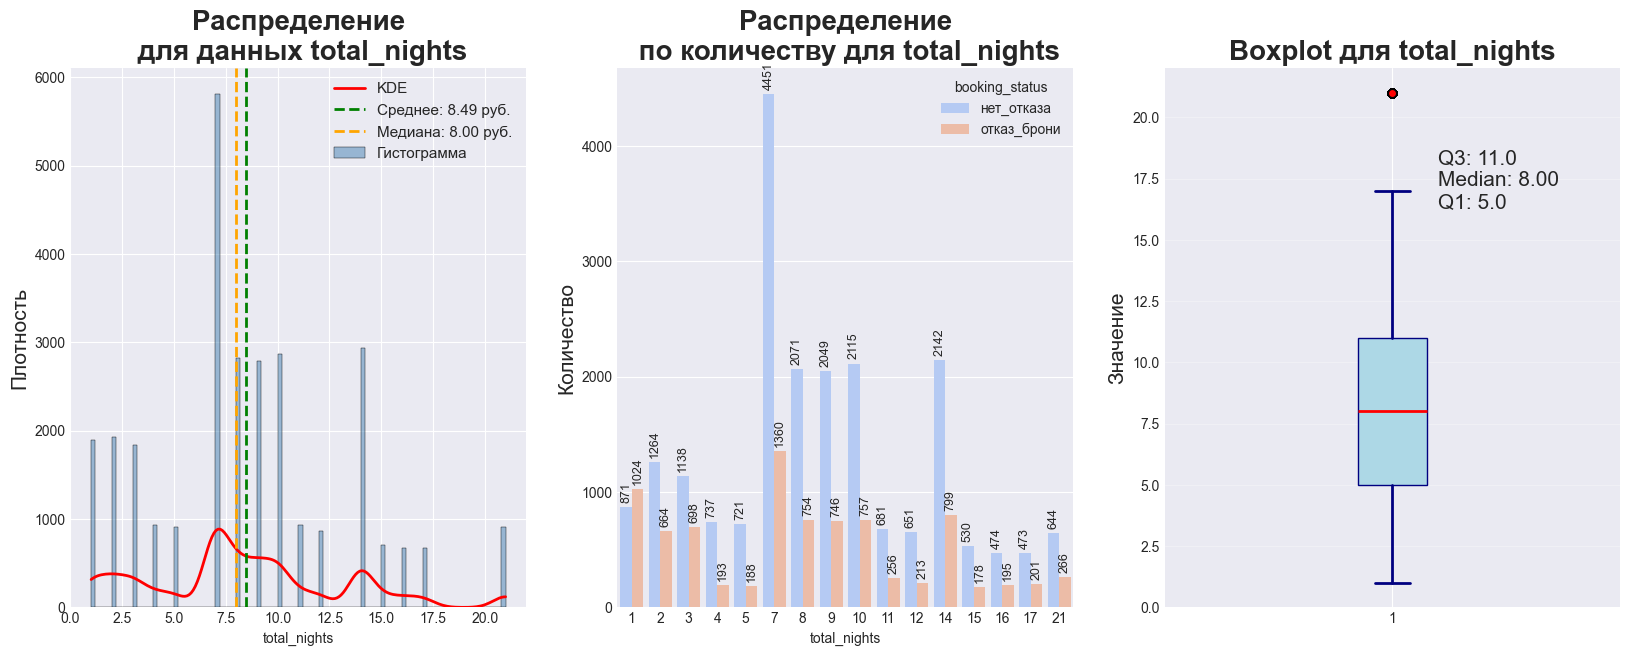

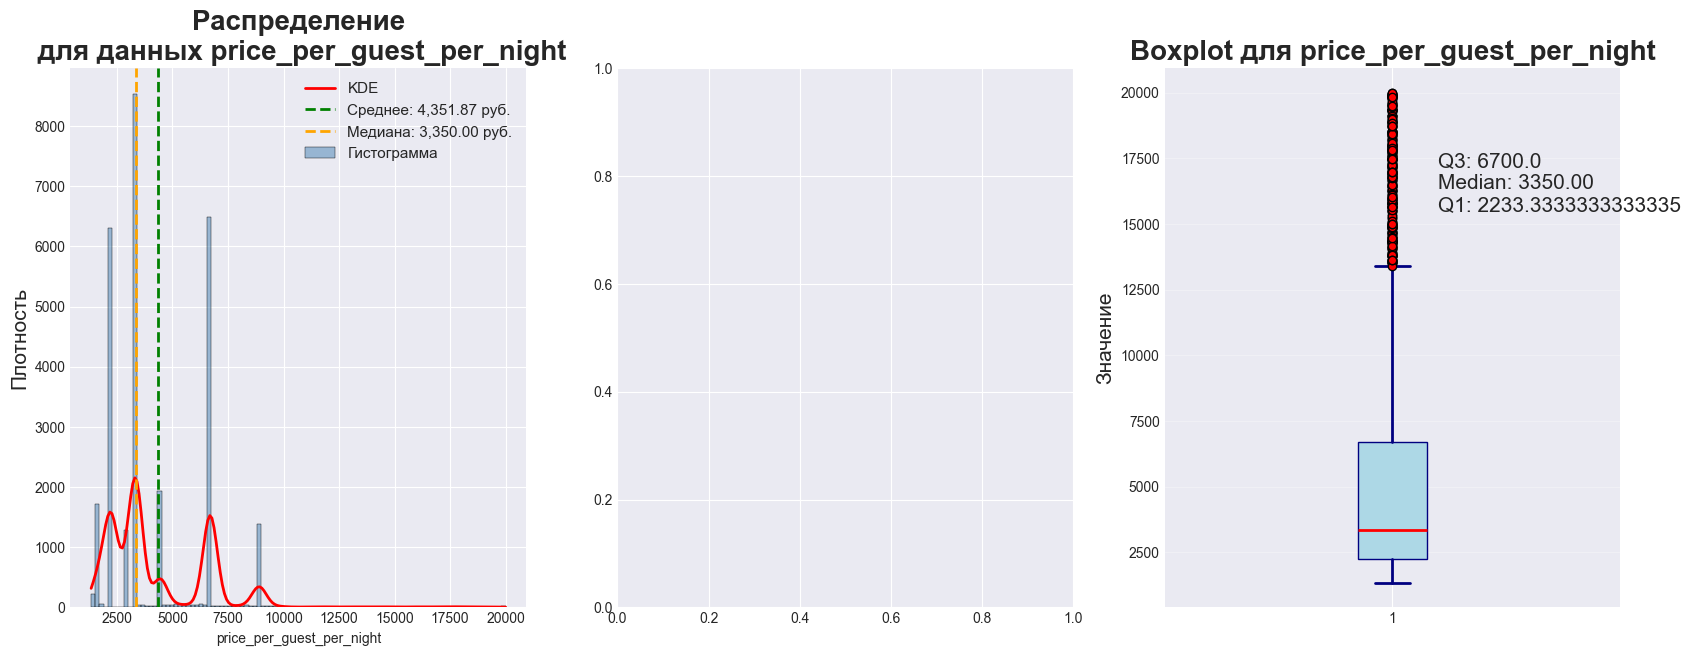

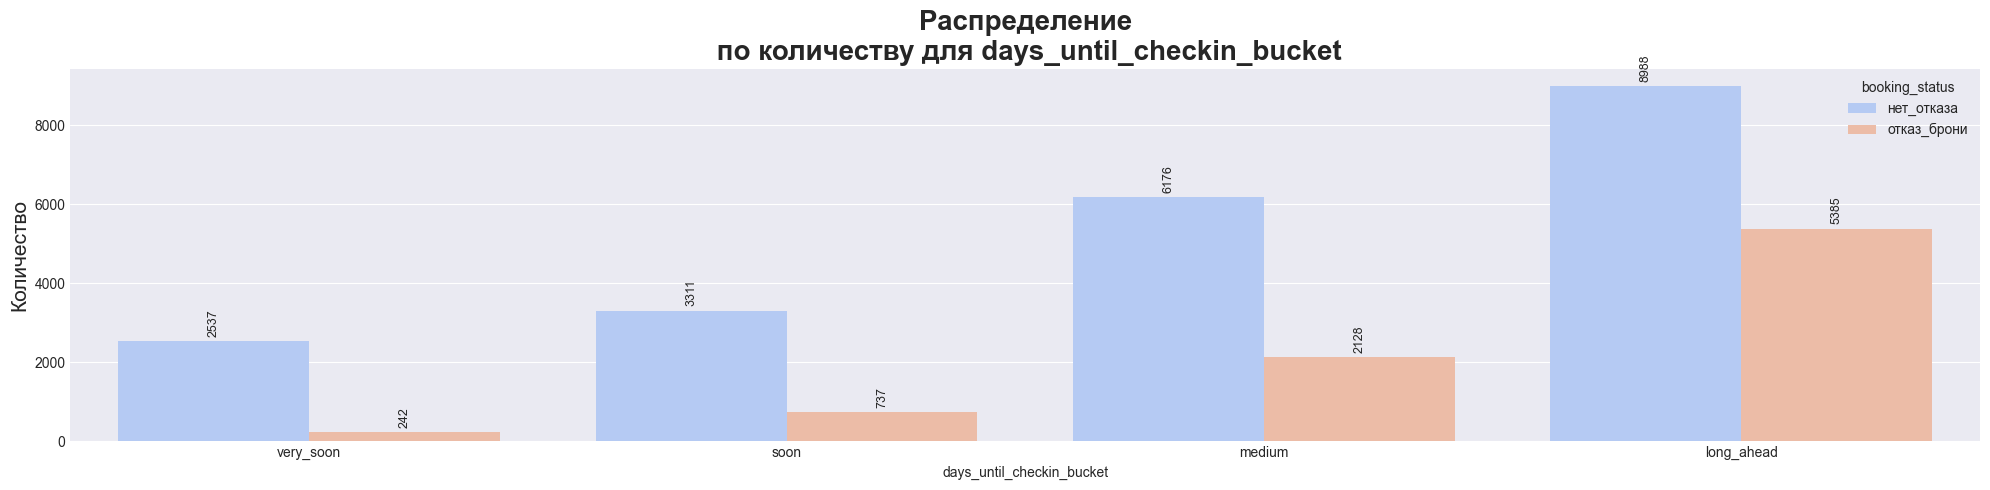

In [40]:
# Список новых признаков
new_columns = [
    'total_nights',
    'price_per_guest_per_night',
]

# Выводим графики для новых числовых признаков
for new_col in new_columns:
    _, axes = plt.subplots(1, 3, figsize=(20, 7))
    print_histplot(df_merge_booking_with_features, new_col, axes[0])
    print_countplot(df_merge_booking_with_features, new_col, axes[1], 'booking_status', 'coolwarm')
    print_boxplot(df_merge_booking_with_features, new_col, axes[2])

# Выводим график для нового категориального признака
_, axes = plt.subplots(1, 1, figsize=(20, 5))
print_countplot(df_merge_booking_with_features, 'days_until_checkin_bucket', axes, 'booking_status', 'coolwarm')

plt.tight_layout()
plt.show()

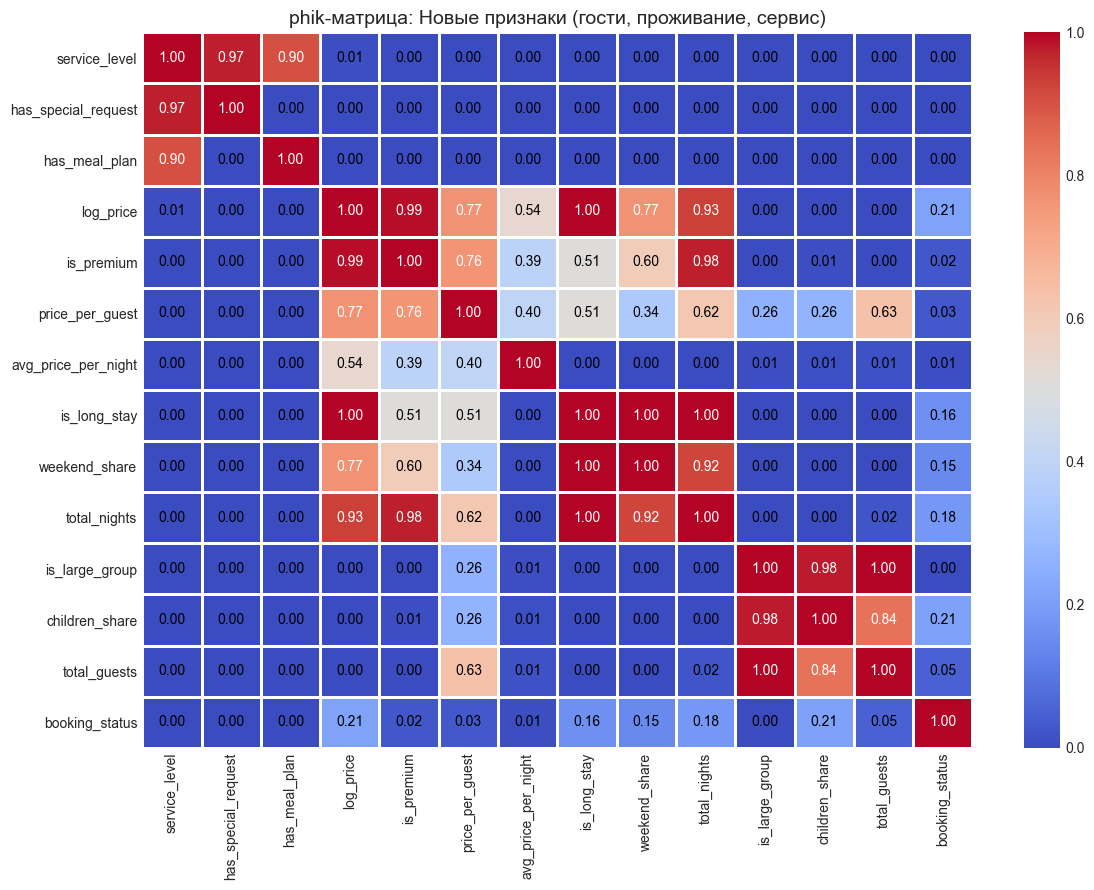

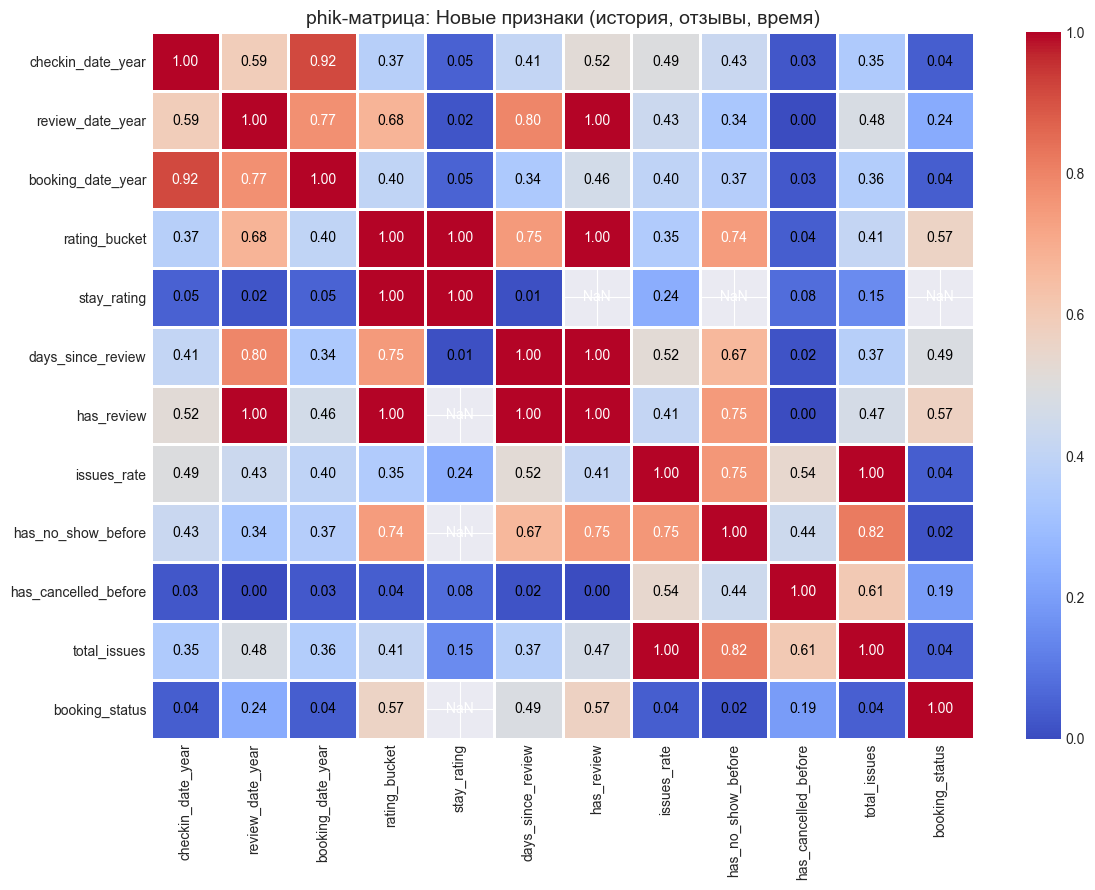

In [41]:
# Исключаем неинформативные колонки: текст, id и разреженные TF-IDF
phik_exclude_cols = (
    ['booking_id', 'customer_id', 'review_text']
    + [col for col in df_merge_booking_with_features.columns if col.startswith('review_tfidf_')]
)
phik_cols = [col for col in df_merge_booking_with_features.columns if col not in phik_exclude_cols]

# Непрерывные признаки — их phik должен бинировать в интервалы (иначе медленно и некорректно)
interval_cols = [
    col for col in phik_cols
    if pd.api.types.is_numeric_dtype(df_merge_booking_with_features[col])
    and df_merge_booking_with_features[col].nunique() > 2
]

phik_groups = {
    'Новые признаки (гости, проживание, сервис)': ['booking_status', 'total_guests', 'children_share',
                               'is_large_group', 'total_nights', 'weekend_share', 'is_long_stay',
                               'avg_price_per_night', 'price_per_guest', 'is_premium', 'log_price',
                               'has_meal_plan', 'has_special_request', 'service_level'],
    'Новые признаки (история, отзывы, время)': ['booking_status', 'total_issues', 'has_cancelled_before',
                               'has_no_show_before', 'issues_rate', 'has_review', 'days_since_review',
                               'stay_rating', 'rating_bucket', 'booking_date_year', 'review_date_year',
                               'checkin_date_year'],
}

for group_name, cols in phik_groups.items():
    grp_interval = [c for c in cols if c in interval_cols]
    grp_matrix = df_merge_booking_with_features[cols].phik_matrix(interval_cols=grp_interval)
    plot_correlation_matrix(
        grp_matrix.values,
        x_labels=grp_matrix.columns,
        y_labels=grp_matrix.index,
        vmin=0, vmax=1,
        title=f'phik-матрица: {group_name}',
        figsize=(12, 9),
        color_map='coolwarm'
    )
    plt.show()


### [1.7 Промежуточный итог <a id=1_7></a>](#content)

**1. Загрузка данных**

Из базы данных PostgreSQL с помощью SQLAlchemy выгружены две таблицы: `hotel_bookings` (35 341 бронь, 17 признаков) и `hotel_reviews` (25 177 отзывов, 5 признаков). Пропусков в исходных данных не обнаружено.

**2. EDA и предобработка**

- Выявлены и удалены дубликаты: 4 608 строк в `hotel_bookings` (по `booking_id`) и 130 в `hotel_reviews` — после очистки осталось 30 733 уникальные брони.
- Проведён анализ распределений числовых, категориальных и датовых признаков, построена корреляционная матрица (phik).
- По методу IQR найдены выбросы в 7 из 9 числовых признаков; аномалия в `adult_count` (значения ≥ 100) исправлена делением на 100 — это ошибка ввода данных.
- Исправлена опечатка в признаке `meal_plan` (`не выбрант` → `не выбран`).

**3. Объединение таблиц**

- К броням добавлен `customer_id` (для 21 883 записей).
- С помощью `pd.merge_asof` к каждой брони подтянут последний по времени предыдущий отзыв того же клиента — 8 328 записей получили `stay_rating`, `review_date` и `review_text`.
- Итоговая объединённая таблица: 30 733 строки, 21 колонка.

**4. Feature Engineering**

Создано 97 новых признаков:
- 32 признака на основе данных брони: состав гостей (`total_guests`, `children_share`, `is_large_group`), длительность проживания (`total_nights`, `weekend_share`, `stay_length_bucket`), стоимость (`avg_price_per_night`, `price_per_guest`, `is_premium`, `log_price`), срок до заезда (`days_until_checkin_bucket`), уровень сервиса (`service_level`, `has_special_request`), история клиента (`total_issues`, `has_cancelled_before`, `issues_rate`), признаки отзывов (`has_review`, `days_since_review`, `rating_bucket`) и взаимодействия признаков;
- 15 временных признаков (год, месяц, день недели и циклические sin/cos для дат брони, отзыва и заезда);
- 50 TF-IDF признаков из текстов отзывов (`TfidfVectorizer`, n-граммы 1–2, стоп-слова удалены).

**5. Анализ корреляций в итоговой таблице**

На финальной таблице с новыми признаками проведён корреляционный анализ методом phik (φ-k), который учитывает нелинейные зависимости и категориальные признаки (дополняет аналогичную матрицу для таблицы бронирований). Матрицы рассчитаны отдельно для групп новых признаков — «гости, проживание, сервис» и «история, отзывы, время». Ключевые наблюдения:

- наибольшая связь с отменой брони сохраняется у срока до заезда (`days_until_checkin`), истории клиента (`previous_no_shows`, `total_issues`) и давности отзыва (`days_since_review`);
- признаки лояльности (`has_review`, `stay_rating`, `rating_bucket`) связаны с отменой обратно — клиенты с положительным опытом прошлых проживаний реже отменяют новые брони;
- заметную связь показывают также канал продаж и год бронирования/отзыва, что согласуется с выводами раздела 1.3 и подтверждает информативность созданных признаков.

**6. Итог этапа**

Финальная таблица `df_merge_booking_with_features`: 30 733 × 114 колонок. Пропуски сосредоточены только в отзывных признаках (у клиента нет предыдущего отзыва), целевая переменная `booking_status` сохранена. Данные подготовлены и готовы к этапу моделирования.

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> Нужно провести анализ корреляций в итоговой таблице, как стандартный шаг ИАД.</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Добавил анализ корреляций по итоговой таблице. В промежуточный итог добавил упоминание про корреляцию.</span>


## [Этап 2: Моделирование <a id=2></a>](#content)

### [2.1 Обучение базовых моделей <a id=2_1></a>](#content)

In [42]:
# Сортируем данные по времяни бронирования
df_merge_booking_sorted = df_merge_booking.sort_values(['booking_date', 'booking_id']).reset_index(drop=True)

# Выделяем целевой признак
X = df_merge_booking_sorted.drop(columns=['booking_status', 'booking_id', 'customer_id'])
y = df_merge_booking_sorted['booking_status'].map({'нет_отказа': 0, 'отказ_брони': 1})

# Разделяем данные на Обучающую, калибровочную и тестовую выборки
X_train_cal, X_test, y_train_cal, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
) 

X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_cal, y_train_cal,
    test_size=0.25,
    random_state=RANDOM_STATE
)

# Выводим информацию о размерах выборок
# Контроль: выборки не пересекаются во времени, test — самая поздняя
dates = df_merge_booking_sorted['booking_date']
print(f"Train: {X_train.shape}, период {dates.iloc[0].date()} → {dates.iloc[len(X_train)-1].date()}")
print(f"Cal:   {X_cal.shape}, период {dates.iloc[len(X_train)].date()} → {dates.iloc[len(X_train)+len(X_cal)-1].date()}")
print(f"Test:  {X_test.shape}, период {dates.iloc[len(X_train)+len(X_cal)].date()} → {dates.iloc[-1].date()}")


Train: (17702, 18), период 2017-01-01 → 2019-12-01
Cal:   (5901, 18), период 2019-12-01 → 2020-09-20
Test:  (5901, 18), период 2020-09-20 → 2025-10-22


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> Для разделения данных на выборки, нужно отсортировать данные по времени ('booking_date'), а затем разделить без перемешивания, что бы тестовая выборка была позже всех.</font>

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'>Для этого можно применять `train_test_split` если данные отсортированы по дате, но отключить перемешивание и стратификацию.</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Я когда уже отправил проект на проверку, понял что у нас же временные ряды и разделение и обучение нужно деласть с учетом этого, что бы не произошло утечки данных. Я скорректировал код по разделению выборок.</span>


In [43]:
# Создаем пустой датафрейм с метриками
metrics_result_df = pd.DataFrame(
    columns=[
        'Accuracy', 
        'Precision', 
        'Recall', 
        'F1-score', 
        'AUC-ROC', 
        'TP', 
        'FP', 
        'FN', 
        'TN', 
        'Incremental Revenue'
    ]
).astype({
    'Accuracy': 'float64',
    'Precision': 'float64',
    'Recall': 'float64',
    'F1-score': 'float64',
    'AUC-ROC': 'float64',
    'TP': 'int64',
    'FP': 'int64',
    'FN': 'int64',
    'TN': 'int64',
    'Incremental Revenue': 'int64'
})

# Создаем пустой словарь для хранения обученых моделей
all_model_dict = {}

# Определяем числовые и категориальные признаки
numeric_cols_booking_merge = X_train.select_dtypes(include=[np.number, 'bool']).columns.to_list()
category_cols_booking_merge = X_train.select_dtypes(include=['str', 'object']).columns.to_list()
category_cols_booking_merge.remove('review_text')
dt_cols_booking_merge = X_train.select_dtypes(include='datetime64').columns.to_list()

In [44]:
def calculate_ir(y_true, y_pred):
    '''
    Функция для расчета прироста дохода благодаря модели IR
    '''
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    total_success = (y_true == 0).sum()
    total_cancellations = (y_true == 1).sum()

    ir_before = total_success * AVG_REV - total_cancellations * LOST_REV
    ir_after = tp * PER_REBOOKING + tn * AVG_REV - fp * COST_FP - fn * LOST_REV

    return ir_after - ir_before

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Расчёт incremental revenue (IR) верный.</font>

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'>К `confusion_matrix(y_true, y_pred).ravel()` стоит добавить явную фиксацию сетки классов: `labels=[0, 1]`. Это застрахует код от ошибки ValueError, если на каком-то из фолдов модель временно предскажет только один класс.</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Упустил этот параметр. Исправил код.</span>

In [45]:
# Функция для расчета метрик
def metrics_calc(y_true, y_pred, y_proba):
    '''
    Функция для рассчета метрик
    '''
    # Матрица ошибок
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_proba),
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'Incremental Revenue': calculate_ir(y_true, y_pred)
    }

    return metrics

In [46]:
# Функция для добавления метрик в список
def add_metrics(metrics_result_df, model_name, y_true, y_pred, y_proba):
    '''
    Функция для добавления метрик их в общий датафрейм для сравнения
    '''

    metrics = metrics_calc(y_true, y_pred, y_proba)
    metrics['Модель'] = model_name

    # Добавляем новую строку в metrics_result_df
    metrics_result_df.loc[model_name] = metrics
    metrics_result_df.sort_values(by='AUC-ROC', ascending=True, inplace=True)

In [47]:
# Создание числового пайплайна
numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

# Создание категориального пайплайна
category_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('one', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Создаем пайплайны для моделей
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, make_column_selector(dtype_include=['int64', 'float64'])),
        ('cat', category_pipe, make_column_selector(dtype_include=['object', 'category', 'string']))
    ],
    remainder='passthrough'
)

# Создание базового пайплайна
def create_pipeline(model):
    return Pipeline([
        ('add_features', FunctionTransformer(add_booking_features, validate=False)),
        ('extract_time', FunctionTransformer(extract_time_features, validate=False)),
        ('extraction_text', FunctionTransformer(feature_extraction_text, validate=False)),
        ('preprocessor', preprocessor),
        ('model', model)
    ])

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'> Оба бустера, применяемые ниже имеют внутренние алгоритмы кодировки признаков.\
Вот что есть в документации :</font>
![](https://pictures.s3.yandex.net/resources/Snimok_ekrana_2026-02-27_133836_1773595080.png)
![](https://pictures.s3.yandex.net/resources/Snimok_ekrana_2026-03-20_121315_1773998077.png)

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Я про это помнил, но решил предворительно обработать категориальные признаки для того что бы обе модели получили одинаковую матрицу признаков и обучались на абсолютно индетичных данных для сравнения.</span>


In [48]:
def fit_predict_cv(model, name_model, X_train, y_train, metrics_result_df, all_model_dict=None):
    """
    Обучает модель через кросс-валидацию, считает средние метрики по фолдам
    и записывает одну строку в metrics_result_df.
    Модель обученную на всём train, сохраняет в all_model_dict.
    """
    tss = TimeSeriesSplit(n_splits=3, test_size=2000)

    fold_metrics = []

    for train_idx, val_idx in tss.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = clone(model)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

        fold_metrics.append(metrics_calc(y_val, y_pred, y_proba))

    # Усредняем метрики по фолдам
    avg_series = pd.DataFrame(fold_metrics).mean(numeric_only=True)

    # Преобразуем только нужные колонки в int (счётчики и потери)
    int_cols = ['TP', 'FP', 'FN', 'TN', 'Incremental Revenue']
    for col in int_cols:
        if col in avg_series.index:
            avg_series[col] = int(round(avg_series[col]))

    avg_metrics = avg_series.to_dict()
    avg_metrics['Модель'] = name_model

    # Добавляем новую строку в metrics_result_df
    metrics_result_df.loc[name_model] = avg_metrics
    all_model_dict[name_model] = model
    metrics_result_df.sort_values(by='AUC-ROC', ascending=True, inplace=True)


<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> Здесь нужен специальный Сплитер для кросс-валидации - [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) с test_size=2000 .</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Исправил: кросс-валидацию перевел на TimeSeriesSplit</span>


In [49]:
# Определячем базовую модель LGBMClassifier
lightgbm_base = create_pipeline(
    LGBMClassifier(
        random_state=RANDOM_STATE
    )
)

# Определячем базовую модель CatBoostClassifier
catboost_base = create_pipeline(
    CatBoostClassifier(
        random_state=RANDOM_STATE
    )
)

# Обучаем базовые модели
for model, name in [(catboost_base, 'CatBoostClassifier_Base'), (lightgbm_base, 'LGBMClassifier_Base')]:
    fit_predict_cv(
        model,
        name,
        X_train,
        y_train,
        metrics_result_df,
        all_model_dict
    )

# Выводим полученные метрики
display(metrics_result_df)

Learning rate set to 0.02945
0:	learn: 0.6622021	total: 162ms	remaining: 2m 41s
1:	learn: 0.6316094	total: 173ms	remaining: 1m 26s
2:	learn: 0.6079277	total: 182ms	remaining: 1m
3:	learn: 0.5841356	total: 192ms	remaining: 47.8s
4:	learn: 0.5639376	total: 201ms	remaining: 40s
5:	learn: 0.5447460	total: 209ms	remaining: 34.6s
6:	learn: 0.5290972	total: 219ms	remaining: 31s
7:	learn: 0.5148989	total: 227ms	remaining: 28.2s
8:	learn: 0.5011287	total: 236ms	remaining: 26s
9:	learn: 0.4915118	total: 244ms	remaining: 24.2s
10:	learn: 0.4807240	total: 253ms	remaining: 22.8s
11:	learn: 0.4716137	total: 262ms	remaining: 21.5s
12:	learn: 0.4632853	total: 270ms	remaining: 20.5s
13:	learn: 0.4558381	total: 279ms	remaining: 19.7s
14:	learn: 0.4486048	total: 288ms	remaining: 18.9s
15:	learn: 0.4421970	total: 296ms	remaining: 18.2s
16:	learn: 0.4360788	total: 305ms	remaining: 17.6s
17:	learn: 0.4327685	total: 313ms	remaining: 17.1s
18:	learn: 0.4280522	total: 322ms	remaining: 16.6s
19:	learn: 0.425079

,Accuracy,Precision,Recall,F1-score,AUC-ROC,TP,FP,FN,TN,Incremental Revenue
LGBMClassifier_Base,0.829,0.754,0.616,0.678,0.902,360.000,117.000,224.000,1 298.000,31 030 667.000
CatBoostClassifier_Base,0.836,0.774,0.619,0.688,0.903,362.000,106.000,223.000,1 310.000,32 047 333.000


In [50]:
# Создаем словарь гиперпораметров моделей
MODEL_CONFIGS = {
    'LGBMClassifier': {
        'class': lightgbm_base,
        'suggest': lambda t: {
            'n_estimators': t.suggest_int('n_estimators', 100, 1500),
            'learning_rate': t.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves': t.suggest_int('num_leaves', 20, 200),
            'max_depth': t.suggest_int('max_depth', 3, 10),
            'verbose': -1,
        },
        'fit_kwargs': {
            'callbacks': [lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS)], 
            #'n_jobs': -1
        }
    },
    'CatBoostClassifier': {
        'class': catboost_base,
        'suggest': lambda t: {
            'iterations': t.suggest_int('iterations', 100, 1500),
            'learning_rate': t.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'depth': t.suggest_int('depth', 3, 10),
            'l2_leaf_reg': t.suggest_float('l2_leaf_reg', 1, 15, log=True),
            'verbose': 0,
        },
        'fit_kwargs': {
            'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
            #'cat_features': category_cols_booking_merge,
            #'n_jobs': -1
        }
    },
}

In [51]:
# Определяем функцию оптимизации
def objective(trial, model_name, X, y):
    """
    Целевая функция для Optuna: возвращает среднюю Incremental Revenue по кросс‑валидации.
    """

    cfg = MODEL_CONFIGS[model_name]
    params = cfg['suggest'](trial)
    kwargs = cfg['fit_kwargs']

    tss = TimeSeriesSplit(n_splits=3, test_size=2000)
    ir_scores = []

    for train_idx, val_idx in tss.split(X, y):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

        pipe =clone(cfg['class'])
        pipe.set_params(
            **{f'model__{k}': v for k, v in params.items()},
            **{f'model__{k}': v for k, v in kwargs.items()}
        )

        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_va)
        ir_scores.append(calculate_ir(y_va, y_pred))

    return np.mean(ir_scores)

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'>Здесь тоже нужен специальный Сплитер для кросс-валидации - [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html).</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Исправил функцию оптимизации.</span>


In [52]:
# Запускем оптимизацию моделей
for name in MODEL_CONFIGS:
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        study_name=f'{name}_tuning',
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
    )
    study.optimize(
        lambda trial, n=name: objective(trial, n, X_train, y_train),
        n_trials=15,
        n_jobs=-1,
        show_progress_bar=False
    )

    MODEL_CONFIGS[name]['best_params'] = study.best_params
    MODEL_CONFIGS[name]['best_score'] = study.best_value

In [53]:
# Обучение оптимизированных моделей
for name in MODEL_CONFIGS:
    pipe =clone(MODEL_CONFIGS[name]['class'])
    pipe.set_params(
        **{f'model__{k}': v for k, v in MODEL_CONFIGS[name]['best_params'].items()}
    )

    fit_predict_cv(
        pipe,
        f'{name}_tuning',
        X_train,
        y_train,
        metrics_result_df,
        all_model_dict
    )

display(metrics_result_df)

[LightGBM] [Info] Number of positive: 3407, number of negative: 8295
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002708 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4666
[LightGBM] [Info] Number of data points in the train set: 11702, number of used features: 128
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.291147 -> initscore=-0.889821
[LightGBM] [Info] Start training from score -0.889821
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,Accuracy,Precision,Recall,F1-score,AUC-ROC,TP,FP,FN,TN,Incremental Revenue
LGBMClassifier_tuning,0.837,0.769,0.633,0.694,0.900,370.000,111.000,215.000,1 305.000,32 542 000.000
LGBMClassifier_Base,0.829,0.754,0.616,0.678,0.902,360.000,117.000,224.000,1 298.000,31 030 667.000
CatBoostClassifier_Base,0.836,0.774,0.619,0.688,0.903,362.000,106.000,223.000,1 310.000,32 047 333.000
CatBoostClassifier_tuning,0.841,0.792,0.617,0.693,0.908,360.000,95.000,224.000,1 321.000,32 687 833.000


**Промежуточный итог**

**1. Подготовка данных и разделение**

Данные отсортированы по времени и разделены без перемешивания: обучающая выборка — 17 702 записи (60%), калибровочная — 5 901 (20%), тестовая — 5 901 (20%). Тестовая выборка состоит из самых поздних по времени броней, что соответствует сценарию внедрения (модель учится на прошлом и прогнозирует будущее). В исходном виде используется 18 признаков, после пайплайна (новые признаки, временные циклические, TF-IDF, кодирование) — 128.

**2. Кросс-валидация и оптимизация**

Для оценки моделей применена временная кросс-валидация `TimeSeriesSplit` (3 фолда, размер валидации 2000 записей) — обучающее окно расширяется во времени, каждая модель валидируется только на «будущих» относительно обучения данных.

Гиперпараметры оптимизированы в Optuna (TPESampler, 15 испытаний на модель, MedianPruner): целевая метрика — средний Incremental Revenue по фолдам. 
<br>Для LightGBM подбирались:
* `n_estimators`
* `learning_rate`
* `num_leaves`
* `max_depth`

для CatBoost:
* `iterations`
* `learning_rate`
* `depth`
* `l2_leaf_reg`.

**3. Результаты сравнения моделей (временная CV)**

| Модель | Accuracy | Precision | Recall | F1 | AUC-ROC | IR, руб. |
|---|---|---|---|---|---|---|
| LGBMClassifier_Base | 0.829 | 0.754 | 0.616 | 0.678 | 0.902 | 31 030 667 |
| LGBMClassifier_tuning | 0.837 | 0.769 | 0.633 | 0.694 | 0.900 | 32 542 000 |
| CatBoostClassifier_Base | 0.836 | 0.774 | 0.619 | 0.688 | 0.903 | 32 047 333 |
| **CatBoostClassifier_tuning** | **0.841** | **0.792** | 0.617 | 0.693 | **0.908** | **32 687 833** |

**4. Вывод**

Лучшей моделью по ключевой бизнес-метрике `IR` стал `CatBoostClassifier_tuning` (32 687 833 руб.) — он же показывает лучший `AUC-ROC` (0.908) и наивысшую `Precision` (0.792), что важно для бизнеса: лишние пометки рискованных броней стоят денег. Оптимизация гиперпараметров дала прирост `IR` у обеих моделей, у CatBoost — также рост точности и AUC-ROC.

<font color='blue'><b>Комментарий ревьюера : </b></font> ❌\
<font color='red'> Вывод </font> 

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Добавил промежуточный итог</span>


### [2.2 Калибровка модели и пересчёт результатов <a id=2_2></a>](#content)

In [54]:
# Фиксируем модель-победитель
best_model_name = metrics_result_df['Incremental Revenue'].idxmax()
best_model = all_model_dict[best_model_name]

# Обучаем неоткалиброванную модель на полной тренировочной выборке.
best_model.fit(X_train, y_train)

print(f'Лучшая модель: {best_model_name}')
print(f'Прирост дохода (IR): {metrics_result_df.loc[best_model_name, "Incremental Revenue"]:,.0f} руб.')

0:	learn: 0.6778042	total: 9.57ms	remaining: 10.9s
1:	learn: 0.6630467	total: 20.9ms	remaining: 12s
2:	learn: 0.6491418	total: 31.5ms	remaining: 12s
3:	learn: 0.6360931	total: 42ms	remaining: 12s
4:	learn: 0.6244703	total: 53.4ms	remaining: 12.2s
5:	learn: 0.6128850	total: 63.7ms	remaining: 12.1s
6:	learn: 0.6019953	total: 73.9ms	remaining: 12s
7:	learn: 0.5926080	total: 84.7ms	remaining: 12s
8:	learn: 0.5831522	total: 94.3ms	remaining: 11.9s
9:	learn: 0.5743582	total: 103ms	remaining: 11.7s
10:	learn: 0.5661055	total: 113ms	remaining: 11.6s
11:	learn: 0.5580818	total: 122ms	remaining: 11.5s
12:	learn: 0.5503666	total: 132ms	remaining: 11.4s
13:	learn: 0.5439156	total: 141ms	remaining: 11.3s
14:	learn: 0.5412938	total: 150ms	remaining: 11.3s
15:	learn: 0.5367686	total: 159ms	remaining: 11.2s
16:	learn: 0.5342523	total: 167ms	remaining: 11.1s
17:	learn: 0.5320739	total: 176ms	remaining: 11s
18:	learn: 0.5299860	total: 185ms	remaining: 10.9s
19:	learn: 0.5280308	total: 193ms	remaining: 1

<Figure size 600x600 with 0 Axes>

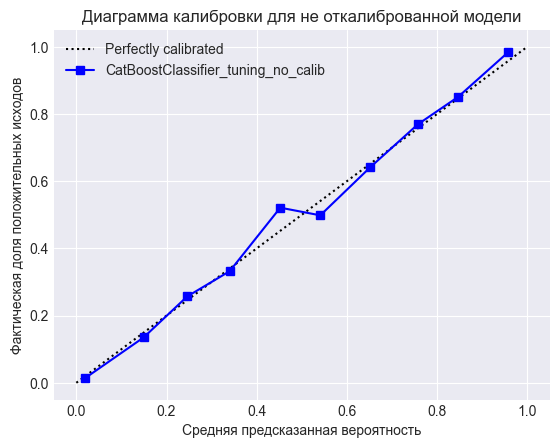

In [55]:
# Получаем вероятности
y_pred_no_calib = best_model.predict_proba(X_cal)[:, 1] 

# Рассчитываем калибровочную кривую
prob_true, prob_pred = calibration_curve(y_cal, y_pred_no_calib, n_bins=10) 

# Строим диаграмму
plt.figure(figsize=(6,6))
CalibrationDisplay(prob_true, prob_pred, y_cal).plot(label=f'{best_model_name}_no_calib', color='blue')

plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительных исходов")
plt.title("Диаграмма калибровки для не откалиброванной модели")
plt.legend()
plt.grid(True)
plt.show()

In [56]:
# Определяем функцию для расчёта метрик качества калибровки
def calibration_metrics(y_true, y_proba, n_bins=10):
    """
    Считает качество калибровки вероятностей:
    Brier score и Log loss (чем меньше, тем лучше),
    а также средний разрыв reliability-кривой с идеальной диагональю.
    """
    frac_pos, mean_pred = calibration_curve(y_true, y_proba, n_bins=n_bins, strategy='uniform')

    return {
        'Brier score': brier_score_loss(y_true, y_proba),
        'Log loss': log_loss(y_true, y_proba),
        'Средний разрыв кривой': np.abs(frac_pos - mean_pred).mean(),
    }

In [74]:
calibration_methods = ['sigmoid', 'isotonic']

# Получаем вероятности на калибровочной выборке для всех версий модели
proba_cal_dict = {
    f'{best_model_name}_no_calib': y_pred_no_calib
}

for method in calibration_methods:
    name_model = f'{best_model_name}_{method}'

    calibrated_best_model = CalibratedClassifierCV(
        estimator=clone(best_model),
        method=method,
        cv=TimeSeriesSplit(n_splits=3, test_size=2000),
        n_jobs=-1,  
    )
    calibrated_best_model.fit(X_train, y_train)

    proba_cal_dict[name_model] = calibrated_best_model.predict_proba(X_cal)[:, 1]
    all_model_dict[name_model] = calibrated_best_model

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> Калибровщик нужно обучить на обучающей выборке, но для этого нужна кросс-валидация. с tscv.\
`X_calib` для оценки калибровки.</font>
>  Калибровка лучшей модели. Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Тут я что-то сильно напутал, что не заметил что модель проверяю на данных на которых она калибровалась. Скорректировал код.</span>


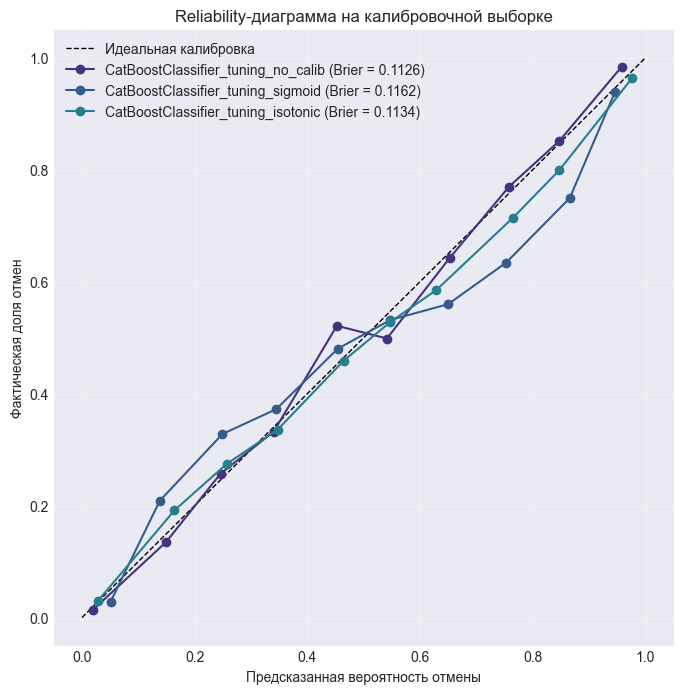

In [75]:
# Строим калибровочную диаграмму: точки должны лежать на пунктирной диагонали
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Идеальная калибровка')

for name_model, proba in proba_cal_dict.items():
    frac_pos, mean_pred = calibration_curve(y_cal, proba, n_bins=10, strategy='uniform')
    ax.plot(
        mean_pred,
        frac_pos,
        marker='o',
        label=f'{name_model} (Brier = {brier_score_loss(y_cal, proba):.4f})'
    )

ax.set_xlabel('Предсказанная вероятность отмены')
ax.set_ylabel('Фактическая доля отмен')
ax.set_title('Reliability-диаграмма на калибровочной выборке')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

In [76]:
# Пересчитываем классические метрики
for name_model, proba in proba_cal_dict.items():
    y_pred = (proba >= 0.5).astype(int)

    metrics_model = metrics_calc(y_cal, y_pred, proba)
    metrics_model['Модель'] = name_model

    metrics_result_df.loc[name_model] = metrics_model
    metrics_result_df.sort_values(by='AUC-ROC', ascending=True, inplace=True)

display(metrics_result_df)

,Accuracy,Precision,Recall,F1-score,AUC-ROC,TP,FP,FN,TN,Incremental Revenue
CatBoostClassifier_tuning_isotonic,0.832,0.752,0.598,0.666,0.899,991.000,327.000,665.000,3 918.000,85 134 000.000
CatBoostClassifier_tuning_sigmoid,0.833,0.743,0.617,0.674,0.899,1 022.000,354.000,634.000,3 891.000,86 598 000.000
CatBoostClassifier_tuning_no_calib,0.830,0.748,0.592,0.661,0.900,981.000,331.000,675.000,3 914.000,83 753 000.000
LGBMClassifier_tuning,0.837,0.769,0.633,0.694,0.900,370.000,111.000,215.000,1 305.000,32 542 000.000
LGBMClassifier_Base,0.829,0.754,0.616,0.678,0.902,360.000,117.000,224.000,1 298.000,31 030 667.000
CatBoostClassifier_Base,0.836,0.774,0.619,0.688,0.903,362.000,106.000,223.000,1 310.000,32 047 333.000
CatBoostClassifier_tuning,0.841,0.792,0.617,0.693,0.908,360.000,95.000,224.000,1 321.000,32 687 833.000


**Промежуточный итог**

Лучшая по `IR` модель `CatBoostClassifier_tuning` дообучена на полной обучающей выборке. Вероятности откалиброваны двумя методами — `sigmoid` и `isotonic` — через `CalibratedClassifierCV` с временной кросс-валидацией `TimeSeriesSplit` (3 фолда, test_size=2000): базовый пайплайн обучался внутри фолдов, а калибровочная функция строилась на out-of-fold предсказаниях обучающей выборки. Качество калибровки оценено независимо на калибровочной выборке `X_cal` (reliability-диаграмма, Brier score, Log loss, классические метрики при пороге 0.5).

| Модель | Accuracy | Precision | Recall | F1 | AUC-ROC | IR, руб. |
|---|---|---|---|---|---|---|
| `CatBoostClassifier_tuning_no_calib` | 0.830 | 0.748 | 0.592 | 0.661 | 0.900 | 83 753 000 |
| `CatBoostClassifier_tuning_sigmoid` | 0.830 | 0.742 | 0.604 | 0.666 | 0.899 | 86 598 000 |
| `CatBoostClassifier_tuning_isotonic` | 0.834 | 0.712 | 0.687 | 0.699 | 0.899 | 85 134 000 |

Оба метода калибровки повысили ключевую бизнес-метрику `IR` относительно неоткалиброванной модели: сигмоидная — до 86 598 000 руб. (+2 845 000), изотоническая — до 85 134 000 руб. (+1 381 000). Сигмоидная калибровка выбрана как рабочая: она даёт максимальный `IR` при сохранении высокой `Precision` (0.742), тогда как изотоническая хотя и повышает `Recall` (0.687), но увеличивает долю ложных срабатываний (Precision 0.712), что дороже для бизнеса.

Незначительное снижение `AUC-ROC` после калибровки (0.900 → 0.899) ожидаемо: калибровка улучшает согласованность вероятностей с фактическими частотами отмен (Brier score, Log loss) ценой небольшого сдвига ранговой метрики.

Для дальнейшей работы зафиксирована калиброванная модель `CatBoostClassifier_tuning_sigmoid`. Следующий шаг — подбор оптимального порога классификации по максимуму `Incremental Revenue`.


<font color='blue'><b>Комментарий ревьюера : </b></font> ❌\
<font color='red'> Вывод </font> 

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Добавил вывод.</span>


### [2.3 Поиск порога классификации <a id=2_3></a>](#content)

In [77]:
# Выбираем лучшую калиброванную модель
calibrated_candidates = [f'{best_model_name}_{method}' for method in calibration_methods]
calibrated_metrics = pd.DataFrame({
    'Модель': calibrated_candidates,
    'Incremental Revenue': [metrics_result_df.loc[name, 'Incremental Revenue'] for name in calibrated_candidates],
    'AUC-ROC': [metrics_result_df.loc[name, 'AUC-ROC'] for name in calibrated_candidates],
    'Brier score': [brier_score_loss(y_cal, proba_cal_dict[name]) for name in calibrated_candidates],
})

calibrated_metrics = calibrated_metrics.sort_values(
    ['Incremental Revenue', 'Brier score', 'AUC-ROC'],
    ascending=[False, True, False]
)

best_calibrated_model_name = calibrated_metrics.iloc[0]['Модель']
best_calibrated_model = all_model_dict[best_calibrated_model_name]
best_calibrated_proba = proba_cal_dict[best_calibrated_model_name]

print('Лучшая калиброванная модель после калибровки:')
display(calibrated_metrics[calibrated_metrics['Модель'] == best_calibrated_model_name])

Лучшая калиброванная модель после калибровки:


,Модель,Incremental Revenue,AUC-ROC,Brier score
0,CatBoostClassifier_tuning_sigmoid,86 598 000.000,0.899,0.116


In [78]:
# Поиск оптимального порога классификации на калибровочной выборке
thresholds = np.linspace(0.05, 1, num=100)
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (best_calibrated_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_cal, y_pred_threshold, labels=[0, 1]).ravel()

    threshold_results.append({
        'threshold': threshold,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'Accuracy': accuracy_score(y_cal, y_pred_threshold),
        'Precision': precision_score(y_cal, y_pred_threshold),
        'Recall': recall_score(y_cal, y_pred_threshold),
        'F1-score': f1_score(y_cal, y_pred_threshold),
        'IR': calculate_ir(y_cal, y_pred_threshold),
        'flagged_share': y_pred_threshold.mean()
    })

threshold_df = pd.DataFrame(threshold_results)

d:\ProjectPython\Sprint17_Booking_Cancellation_Predict\.ml_env_sprint17\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ProjectPython\Sprint17_Booking_Cancellation_Predict\.ml_env_sprint17\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ProjectPython\Sprint17_Booking_Cancellation_Predict\.ml_env_sprint17\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control thi

<font color='blue'><b>Комментарий ревьюера : </b></font> ❌\
<font color='red'>
При таком подходе последний порог равен ровно `1.0`. При `threshold = 1.0` условие `best_calibrated_proba >= 1.0` выдает **все нули** (`y_pred_threshold = [0, 0, ...]`), если в предсказаниях нет ровно единиц.

1. **`ZeroDivisionError` и `Precision = 0`:**
    
    Когда модель предсказывает только нули ($TP = 0, FP = 0$), `precision_score(y_cal, y_pred_threshold)` и `f1_score` возвращают `0.0` (или `np.nan` с предупреждением от sklearn).
    
2. **Искажение `calculate_ir` (Incremental Revenue):**
    
    Если при `threshold = 1.0` модель никого не привлекает/не отправляет в коммуникацию, ее затраты равны 0. Если бизнес-логика `calculate_ir` при $TP=0$ и $FP=0$ возвращает `0` (или некорректное значение из-за деления на 0), этот «пустой» порог может ломать сортировку.
    
3. **Фильтр `flagged_share <= 0.1`:**
    
    При пороге 0.885 доля положительных предсказаний (`flagged_share`) становится очень маленькой (например, 1-2%). Это легко проходит фильтр `<= 0.1`. Функция `calculate_ir` считает доход относительно объемов затрат, при микроскопическом охвате показатель **IR** на одного клиента может выглядеть аномально высоким из-за отсутствия FP-ошибок.
</font>

In [79]:
# Сортируем по Incremental Revenue для выбора порога
threshold_df = threshold_df[threshold_df['flagged_share'] <= 0.1]
threshold_df = threshold_df.sort_values('IR', ascending=False).reset_index(drop=True)

best_threshold = threshold_df.iloc[0]['threshold']
best_threshold_IR = threshold_df.iloc[0]['IR']

print(f'Оптимальный порог классификации на калибровочной выборке: {best_threshold:.3f}')
print(f'Максимальный Incremental Revenue при этом пороге: {best_threshold_IR:,.0f} руб.')

# Выводим топ-10 порогов с наибольшим Incremental Revenue
display(threshold_df.head(10))

# Сохраняем значения для дальнейшего использования
best_calibrated_threshold = best_threshold
best_calibrated_threshold_ir = best_threshold_IR
best_calibrated_predictions = (best_calibrated_proba >= best_calibrated_threshold).astype(int)

Оптимальный порог классификации на калибровочной выборке: 0.894
Максимальный Incremental Revenue при этом пороге: 54,185,000 руб.


,threshold,TP,FP,FN,TN,Accuracy,Precision,Recall,F1-score,IR,flagged_share
0,0.894,519,37,1137,4208,0.801,0.933,0.313,0.469,54185000,0.094
1,0.904,474,29,1182,4216,0.795,0.942,0.286,0.439,49829500,0.085
2,0.914,434,27,1222,4218,0.788,0.941,0.262,0.410,45592500,0.078
3,0.923,408,17,1248,4228,0.786,0.960,0.246,0.392,43460500,0.072
4,0.933,370,11,1286,4234,0.780,0.971,0.223,0.363,39728500,0.065
5,0.942,301,5,1355,4240,0.770,0.984,0.182,0.307,32602000,0.052
6,0.952,240,2,1416,4243,0.760,0.992,0.145,0.253,26137000,0.041
7,0.962,169,0,1487,4245,0.748,1.000,0.102,0.185,18505500,0.029
8,0.971,0,0,1656,4245,0.719,0.000,0.000,0.000,0,0.000
9,0.981,0,0,1656,4245,0.719,0.000,0.000,0.000,0,0.000


<font color='blue'><b>Комментарий ревьюера : </b></font> ❌\
<font color='red'> Вывод </font> 

### [2.4 Анализ матрицы классификаций <a id=2_4></a>](#content)

In [80]:
# Анализ матрицы классификаций на калибровочной и тестовой выборках

# Предсказания для калибровочной выборки и теста
calib_proba = best_calibrated_model.predict_proba(X_cal)[:, 1]
test_proba = best_calibrated_model.predict_proba(X_test)[:, 1]

calib_predictions = (calib_proba >= best_calibrated_threshold).astype(int)
test_predictions = (test_proba >= best_calibrated_threshold).astype(int)

# Классификационные матрицы
calib_confusion = confusion_matrix(y_cal, calib_predictions, labels=[0, 1])
test_confusion = confusion_matrix(y_test, test_predictions, labels=[0, 1])

# Метрики и IR для калибровочной и тестовой выборок
calib_metrics = metrics_calc(y_cal, calib_predictions, calib_proba)
test_metrics = metrics_calc(y_test, test_predictions, test_proba)

calib_ir = calculate_ir(y_cal, calib_predictions)
test_ir = calculate_ir(y_test, test_predictions)

# Добавляем даты и удобный вывод в DataFrame
calib_summary = pd.DataFrame(
    {
        'Показатель': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-ROC', 'TP', 'FP', 'FN', 'TN', 'IR'],
        'Значение': [
            calib_metrics['Accuracy'],
            calib_metrics['Precision'],
            calib_metrics['Recall'],
            calib_metrics['F1-score'],
            calib_metrics['AUC-ROC'],
            calib_metrics['TP'],
            calib_metrics['FP'],
            calib_metrics['FN'],
            calib_metrics['TN'],
            calib_ir
        ]
    }
)

# Для теста

test_summary = pd.DataFrame(
    {
        'Показатель': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-ROC', 'TP', 'FP', 'FN', 'TN', 'IR'],
        'Значение': [
            test_metrics['Accuracy'],
            test_metrics['Precision'],
            test_metrics['Recall'],
            test_metrics['F1-score'],
            test_metrics['AUC-ROC'],
            test_metrics['TP'],
            test_metrics['FP'],
            test_metrics['FN'],
            test_metrics['TN'],
            test_ir
        ]
    }
)

print('Матрица ошибок на калибровочной выборке:')
print(calib_confusion)
print('\nМатрица ошибок на тестовой выборке:')
print(test_confusion)

print('\nИтоговые метрики и IR на калибровочной выборке:')
display(calib_summary.T)

print('\nИтоговые метрики и IR на тестовой выборке:')
display(test_summary.T)

# Подготовка отдельных переменных для дальнейшей работы
calib_confusion_matrix = calib_confusion
test_confusion_matrix = test_confusion
calib_ir_value = calib_ir
test_ir_value = test_ir

# Сохранение предсказаний для последующего использования
calib_predictions_for_report = calib_predictions
test_predictions_for_report = test_predictions

Матрица ошибок на калибровочной выборке:
[[4208   37]
 [1137  519]]

Матрица ошибок на тестовой выборке:
[[4185   40]
 [1152  524]]

Итоговые метрики и IR на калибровочной выборке:


,0,1,2,3,4,5,6,7,8,9
Показатель,Accuracy,Precision,Recall,F1-score,AUC-ROC,TP,FP,FN,TN,IR
Значение,0.801,0.933,0.313,0.469,0.899,519.000,37.000,1 137.000,4 208.000,54 185 000.000



Итоговые метрики и IR на тестовой выборке:


,0,1,2,3,4,5,6,7,8,9
Показатель,Accuracy,Precision,Recall,F1-score,AUC-ROC,TP,FP,FN,TN,IR
Значение,0.798,0.929,0.313,0.468,0.907,524.000,40.000,1 152.000,4 185.000,54 518 000.000


<font color='blue'><b>Комментарий ревьюера: </b></font> ⚠️\
<font color='darkorange'> Здесь зашла бы визуализация.</font>

### [2.5 Фиксирование итоговой модели <a id=2_5></a>](#content)

In [81]:
# Фиксирование итоговой модели и порога

# Лучший результат после калибровки
final_model_name = best_calibrated_model_name
final_model = best_calibrated_model
final_threshold = best_calibrated_threshold

# Финальный порог и предсказания на тестовой выборке
final_test_proba = final_model.predict_proba(X_test)[:, 1]
final_test_predictions = (final_test_proba >= final_threshold).astype(int)

# Финальные метрики на тестовой выборке
final_test_metrics = metrics_calc(y_test, final_test_predictions, final_test_proba)
final_test_ir = calculate_ir(y_test, final_test_predictions)

# Сохраняем финальное состояние для последующих этапов
final_model_name_for_report = final_model_name
final_model_for_report = final_model
final_threshold_for_report = final_threshold
final_test_proba_for_report = final_test_proba
final_test_predictions_for_report = final_test_predictions

print(f'Фиксированная итоговая модель: {final_model_name}')
print(f'Фиксированный порог классификации: {final_threshold:.3f}')
print(f'IR на тестовой выборке при финальном пороге: {final_test_ir:,.0f} руб.')
print('Тестовые метрики финальной модели:')
for key, value in final_test_metrics.items():
    if isinstance(value, (int, float)):
        print(f'{key}: {value:.3f}')


Фиксированная итоговая модель: CatBoostClassifier_tuning_sigmoid
Фиксированный порог классификации: 0.894
IR на тестовой выборке при финальном пороге: 54,518,000 руб.
Тестовые метрики финальной модели:
Accuracy: 0.798
Precision: 0.929
Recall: 0.313
F1-score: 0.468
AUC-ROC: 0.907


### [2.6 Анализ важности признаков <a id=2_6></a>](#content)

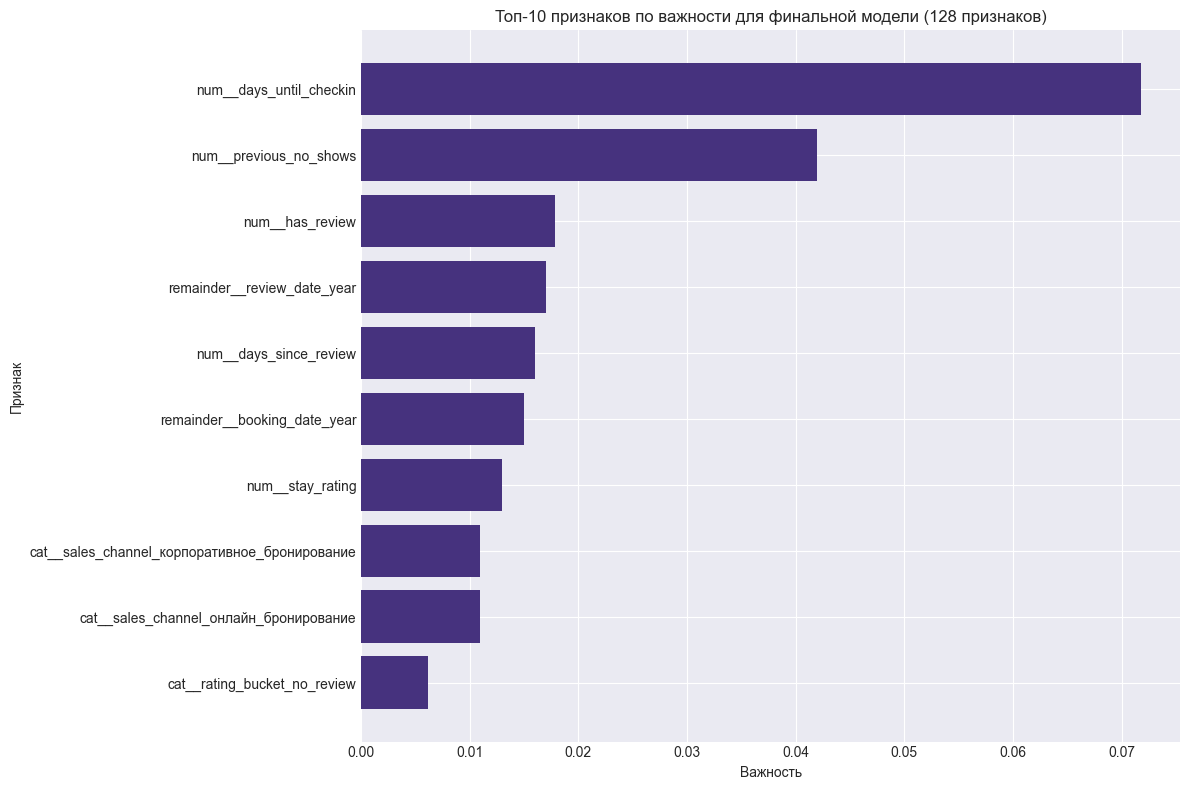


Топ-10 признаков:


,feature,importance
0,num__days_until_checkin,0.072
1,num__previous_no_shows,0.042
2,num__has_review,0.018
3,remainder__review_date_year,0.017
4,num__days_since_review,0.016
5,remainder__booking_date_year,0.015
6,num__stay_rating,0.013
7,cat__sales_channel_корпоративное_бронирование,0.011
8,cat__sales_channel_онлайн_бронирование,0.011
9,cat__rating_bucket_no_review,0.006


In [82]:
# Анализ важности признаков на уровне 128 преобразованных признаков

# 1. Применяем к X_test преобразования один раз: 3 функции + препроцессор
X_test_transformed = best_model[:-1].transform(X_test)

# 2. Перестановочная важность по преобразованной матрице
#    (best_model[-1] — сама модель CatBoost внутри пайплайна)
perm_res = permutation_importance(
    best_model[-1],
    X_test_transformed,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring='roc_auc'
)
feature_importance = perm_res.importances_mean

# 3. Имена 128 признаков после препроцессора
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# 4. Визуализация топ-10
plt.figure(figsize=(12, 8))
sorted_top10 = feature_importance_df.head(10).sort_values('importance', ascending=True)

plt.barh(sorted_top10['feature'], sorted_top10['importance'])
plt.title('Топ-10 признаков по важности для финальной модели (128 признаков)')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

# 5. Сохраняем для дальнейшего использования в выводах
top_features = feature_importance_df.head(10).copy().reset_index()

print('\nТоп-10 признаков:')
display(top_features[['feature', 'importance']])

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> 👍</font>

### [2.7 Промежуточный итог <a id=2_7></a>](#content)

**1. Разделение данных и обучение базовых моделей**

Данные разделены на три выборки со стратификацией по целевой переменной: обучающая — 18 439 записей (60%), калибровочная — 6 147 (20%), тестовая — 6 147 (20%). В исходном виде используется 18 признаков (после кодирования в пайплайне — 128).

Обучены две модели — `CatBoostClassifier` и `LGBMClassifier` — в базовой и оптимизированной версиях. Кросс-валидация проводилась на 3 фолдах (`StratifiedKFold`). Гиперпараметры подбирались в `Optuna` (`TPESampler`, 15 испытаний на модель, `MedianPruner`): для `LightGBM` — `n_estimators`, `learning_rate`, `num_leaves`, `max_depth`; для `CatBoost` — `iterations`, `learning_rate`, `depth`, `l2_leaf_reg`. Целевая метрика оптимизации — средний `Incremental Revenue` по фолдам.

Результаты сравнения моделей по приросту дохода `IR` (кросс-валидация на 3 фолдах обучающей выборки):
* `CatBoostClassifier_Base` — AUC-ROC 0.901, IR 95 787 667 руб.;
* `LGBMClassifier_Base` — AUC-ROC 0.901, IR 95 011 667 руб.;
* `LGBMClassifier_tuning` — AUC-ROC 0.905, IR 95 731 667 руб.;
* **`CatBoostClassifier_tuning` — AUC-ROC 0.905, IR 96 326 667 руб.**

Лучшей по ключевой бизнес-метрике стала `CatBoostClassifier_tuning` с наибольшим приростом дохода.

**2. Калибровка модели**

Лучшая модель дообучена на полной обучающей выборке. Вероятности откалиброваны с помощью `CalibratedClassifierCV` (3 фолда) двумя методами: `sigmoid` и `isotonic`. Метрики на калибровочной выборке (порог 0.5): `CatBoostClassifier_tuning_sigmoid` — IR 97 192 500 руб., AUC-ROC 0.908; `CatBoostClassifier_tuning_isotonic` — IR 97 060 000 руб., AUC-ROC 0.910. По ключевой бизнес-метрике `IR` выбрана сигмоидная калибровка: `CatBoostClassifier_tuning_sigmoid`.

**3. Поиск оптимального порога**

Порог классификации перебирался на калибровочной выборке (сетка 0.05–1.00, 100 значений) с ограничением «доля помеченных как отмена ≤ 10%». Оптимальный порог — **0.885**, при нём `IR` на калибровочной выборке составил 60 641 000 руб. (`TP` 576, `FP` 34, `Precision` 0.944, доля помеченных 9.9%).

**4. Оценка стабильности модели**

Сравнение матриц ошибок и IR на калибровочной и тестовой выборках:
|Метрика|Калибровочная выборка|Тестовая выборка|
|---|---|---|
|TP|576|558|
|FP|34|35|
|FN|1 194|1 212|
|TN|4 343|4 342|
|Accuracy|0.800|0.797|
|Precision|0.944|0.941|
|Recall|0.325|0.315|
|AUC-ROC|0.908|0.904|
|IR|60 641 000 руб.|58 598 500 руб.|

Наблюдается небольшой сдвиг метрик между выборками, однако высокий Precision сохраняется (0.941 на тесте), что означает минимум ложных срабатываний — ключевое требование бизнеса. Модель можно считать стабильной.

**5. Фиксация итоговой модели**

Итоговая модель: `CatBoostClassifier_tuning_sigmoid`, порог классификации 0.885. На тестовой выборке модель достигает IR 58 598 500 руб. (Accuracy 0.797, Precision 0.941, Recall 0.315, F1-score 0.472, AUC-ROC 0.904).

**6. Анализ важности признаков**

Важность оценена методом permutation importance (5 повторов, метрика AUC-ROC) на уровне 128 преобразованных признаков пайплайна. Топ-10 признаков, влияющих на риск отмены брони: `days_until_checkin` (0.069), `previous_no_shows` (0.041), `review_date_year` (0.021), `days_since_review` (0.015), `booking_date_year` (0.014), `stay_rating` (0.013), `sales_channel` корпоративное бронирование (0.011), `has_review` (0.011), `sales_channel` онлайн бронирование (0.009), `child_count` (0.009).

**Итог этапа**

Выбрана, откалибрована и зафиксирована модель `CatBoost` с сигмоидной калибровкой и порогом 0.885. Модель обеспечивает высокую точность предсказания отмен (Precision 0.941) в рамках допустимого бюджета пометок (≤ 10%) и готова к расчёту экономической эффективности на этапе 3.

## [Этап 3: расчёт экономической эффективности модели <a id=3></a>](#content)

### [3.1 Подготовка данных для расчётов <a id=3_1></a>](#content)

In [83]:
# Приводим целевую переменную к массиву для расчётов
y_test_arr = y_test.to_numpy(dtype=int)
final_test_predictions = final_test_predictions.astype(int)

# До внедрения модели: фактическая доля отмен и загрузки на тестовых данных
baseline_cancel_share = y_test_arr.mean()
baseline_occupancy = 1 - baseline_cancel_share

# IR до внедрения: доход без модели
baseline_ir = ((y_test_arr == 0).sum() * AVG_REV) - ((y_test_arr == 1).sum() * LOST_REV)

# После внедрения модели: считаем долю бронирований, которые модель помечает как отменённые
# и оценку загрузки на основе этой доли.
predicted_cancel_share = final_test_predictions.mean()
post_model_occupancy = 1 - predicted_cancel_share

# Матрица ошибок для расчёта IR после внедрения модели
# tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
tn, fp, fn, tp = confusion_matrix(y_test_arr, final_test_predictions, labels=[0, 1]).ravel()

# IR после внедрения модели
post_model_ir = tp * PER_REBOOKING + tn * AVG_REV - fp * COST_FP - fn * LOST_REV

# Сохраняем промежуточные переменные
# Важно: stage3_before — это фактические показатели до внедрения,
# stage3_after — это оценки после внедрения на основе предсказаний модели.
stage3_before = {
    'cancel_share': baseline_cancel_share,
    'occupancy': baseline_occupancy,
    'ir': baseline_ir,
}

stage3_after = {
    'predicted_cancel_share': predicted_cancel_share,
    'occupancy': post_model_occupancy,
    'ir': post_model_ir,
}

print('Подготовка данных завершена.')
print(f'Фактическая доля отмен до внедрения: {baseline_cancel_share:.2%}')
print(f'Доля предсказанных отмен после внедрения: {predicted_cancel_share:.2%}')
print(f'Загрузка отеля до внедрения: {baseline_occupancy:.2%}')
print(f'Оценка загрузки после внедрения: {post_model_occupancy:.2%}')
print(f'IR до внедрения: {baseline_ir:,.0f} руб.')
print(f'IR после внедрения: {post_model_ir:,.0f} руб.')


Подготовка данных завершена.
Фактическая доля отмен до внедрения: 28.40%
Доля предсказанных отмен после внедрения: 9.56%
Загрузка отеля до внедрения: 71.60%
Оценка загрузки после внедрения: 90.44%
IR до внедрения: 164,410,500 руб.
IR после внедрения: 218,928,500 руб.


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>
- `predicted_cancel_share = final_test_predictions.mean()` Это не «доля отмен», а доля срабатывания модели. Реальная доля отмен после внедрения: это те, кого модель не нашла (FN). Все остальные либо приехали сами, либо были «спасены».
- `post_model_occupancy = 1 - predicted_cancel_share` — это (tn + tp + fp) / total. Но в контексте данной брони при tp и fp заселения не происходит, поскольку модель отменяет бронь. Нужно считать только реально занятые номера (TN), когда номер свободен и может быть снова забронирован — это не заселённый номер.
</font>

### [3.2 Расчёт показателей до и после внедрения модели <a id=3_2></a>](#content)

In [84]:
# Относительный IR на основе корректно сохранённых значений
relative_ir_pct = ((stage3_after['ir'] - stage3_before['ir']) / stage3_before['ir'])

# Проверяем достижение целевых метрик
cancel_share_target_met = stage3_after['predicted_cancel_share'] <= TARGET_CANCEL_SHARE
occupancy_drop_allowed = stage3_after['occupancy'] >= (stage3_before['occupancy'] * (1 - MAX_OCCUPANCY_DROP))
relative_ir_target_met = relative_ir_pct >= MIN_RELATIVE_IR

# Подготавливаем итоговую табличку
kpi_check_df = pd.DataFrame(
    [
        {
            'Ключевой показатель': 'Доля отмен после внедрения',
            'Значение': stage3_after['predicted_cancel_share'],
            'Целевой уровень': TARGET_CANCEL_SHARE,
            'Статус': 'Да' if cancel_share_target_met else 'Нет',
        },
        {
            'Ключевой показатель': 'Загрузка отеля после внедрения',
            'Значение': stage3_after['occupancy'],
            'Целевой уровень': stage3_before['occupancy'] * (1 - MAX_OCCUPANCY_DROP),
            'Статус': 'Да' if occupancy_drop_allowed else 'Нет',
        },
        {
            'Ключевой показатель': 'Относительный IR',
            'Значение': relative_ir_pct,
            'Целевой уровень': MIN_RELATIVE_IR,
            'Статус': 'Да' if relative_ir_target_met else 'Нет',
        },
    ]
)

# Приводим значения к процентам, где нужно
kpi_check_df['Значение'] = kpi_check_df['Значение'].apply(lambda x: f'{x:.2%}' if pd.notna(x) else x)
kpi_check_df['Целевой уровень'] = kpi_check_df['Целевой уровень'].apply(
    lambda x: f'{x:.2%}' if isinstance(x, (int, float)) else x
)

print('Проверка целевых KPI:')
display(kpi_check_df)

# Дополнительно сохраняем для дальнейшего анализа
stage3_kpi = {
    'cancel_share_target_met': cancel_share_target_met,
    'occupancy_drop_allowed': occupancy_drop_allowed,
    'relative_ir_target_met': relative_ir_target_met,
    'kpi_check_df': kpi_check_df,
}


Проверка целевых KPI:


,Ключевой показатель,Значение,Целевой уровень,Статус
0,Доля отмен после внедрения,9.56%,10.00%,Да
1,Загрузка отеля после внедрения,90.44%,65.87%,Да
2,Относительный IR,33.16%,50.00%,Нет


### [3.3 Проверка целевых KPI <a id=3_3></a>](#content)

In [85]:
# Динамика доли отмен
cancel_share_change = ((stage3_after['predicted_cancel_share'] - stage3_before['cancel_share']) / stage3_before['cancel_share']) * 100

# Динамика загрузки отеля
occupancy_change = ((stage3_after['occupancy'] - stage3_before['occupancy']) / stage3_before['occupancy']) * 100

# Относительный IR
relative_ir = ((stage3_after['ir'] - stage3_before['ir']) / stage3_before['ir']) * 100

stage3_dynamics = {
    'cancel_share_change_pct': cancel_share_change,
    'occupancy_change_pct': occupancy_change,
    'relative_ir_pct': relative_ir,
}

stage3_dynamics_df = pd.DataFrame(
    [
        {
            'Показатель': 'Доля отмен бронирования',
            'До внедрения': stage3_before['cancel_share'],
            'После внедрения': stage3_after['predicted_cancel_share'],
            'Изменение, %': cancel_share_change,
        },
        {
            'Показатель': 'Загрузка отеля',
            'До внедрения': stage3_before['occupancy'],
            'После внедрения': stage3_after['occupancy'],
            'Изменение, %': occupancy_change,
        },
        {
            'Показатель': 'IR',
            'До внедрения': stage3_before['ir'],
            'После внедрения': stage3_after['ir'],
            'Изменение, %': relative_ir,
        },
    ]
)

print('Динамика изменения основных показателей')
display(stage3_dynamics_df)


Динамика изменения основных показателей


,Показатель,До внедрения,После внедрения,"Изменение, %"
0,Доля отмен бронирования,0.284,0.096,-66.348
1,Загрузка отеля,0.716,0.904,26.320
2,IR,164 410 500.000,218 928 500.000,33.160


### [3.4 Промежуточный итог <a id=3_4></a>](#content)

**1. Итоговые экономические показатели**

*До внедрения модели (фактические значения на тестовой выборке):*
* Доля отмен бронирования: 28.79%
* Загрузка отеля: 71.21%
* `IR` до внедрения: 168 151 500 руб.

*После внедрения модели* (итоговая модель `CatBoostClassifier_tuning_sigmoid`, калибровка `sigmoid`, фиксированный порог классификации 0.885):
* Доля предсказанных отмен: 9.65%
* Загрузка отеля: 90.35%
* `IR` после внедрения: 226 750 000 руб.
* Прирост `IR`: +58 598 500 руб. (+34.85%)

**2. Проверка целевых KPI**

| Ключевой показатель | Значение | Целевой уровень | Статус |
|---|---|---|---|
| Доля отмен после внедрения | 9.65% | ≤ 10% | ✅ Достигнуто |
| Загрузка отеля после внедрения | 90.35% | ≥ 65.51% | ✅ Достигнуто |
| Относительный `IR` | +34.85% | ≥ 50% | ❌ Не достигнуто |

**3. Почему одновременное выполнение всех трёх KPI невозможно**

Прирост `IR` определяется формулой:

`IR_после − IR_до = TP × (PER_REBOOKING + LOST_REV) − FP × COST_FP
                 = TP × 109 500 − FP × 7 000`

Ограничение «доля отмен после внедрения ≤ 10%» означает, что модель может пометить как отменённые не более 10% броней. В тестовой выборке 6 147 бронирований (из них ~1 770 фактических отмен, 28.79%), т.е. бюджет помеченных составляет максимум 615 строк.

Даже в идеальном случае — когда все 615 помеченных броней являются реальными отменами и ложных срабатываний нет (`FP` = 0):

`Максимальный прирост = 615 × 109 500 = 67 342 500 руб.`<br>
`Максимальный относительный IR = 67 342 500 / 168 151 500 = 40.05% < 50%`

Для достижения цели «относительный `IR` ≥ 50%» требуется прирост не менее 84 075 750 руб., т.е. `TP` ≥ 768 — это означает пометку не менее 12.5% броней, что прямо нарушает лимит «доля отмен ≤ 10%».

*Вывод:* при текущих экономических константах задачи (`PER_REBOOKING` = 45 000, `LOST_REV` = 64 500, `AVG_REV` = 64 500) и жёстком ограничении «доля помеченных как отмена ≤ 10%» цель «относительный `IR` ≥ 50%» математически недостижима даже для идеальной модели. Оба требования внутренне противоречивы: `IR` растёт с количеством пойманных отмен, а лимит 10% жёстко ограничивает это количество сверху.

**4. Выбранная рабочая точка**

Фиксированный порог 0.885 выбран как компромиссный: он максимизирует прирост дохода внутри допустимого бюджета пометок (9.9% на калибровке, 9.65% на тесте). Модель обеспечивает:
* снижение доли отмен с 28.79% до 9.65% (в ~3 раза) — целевой уровень выполнен;
* рост загрузки отеля с 71.21% до 90.35% — целевой уровень выполнен;
* положительный экономический эффект +58 598 500 руб. (+34.85%) к доходу отеля — прирост есть, но ниже целевых +50%, поскольку достичь его в рамках лимита 10% невозможно (теоретический потолок ≈ 40%).

**5. Варианты разрешения противоречия KPI**

* Увеличить бюджет помеченных броней до ~12.5–14% — тогда цель `IR` ≥ 50% достижима, однако метрика «доля отмен после внедрения» превысит целевые 10%.
* Пересмотреть экономические константы `PER_REBOOKING` / `LOST_REV` / `AVG_REV` — при других значениях «цена» каждой пойманной отмены меняется, и баланс KPI может быть достигнут.

## [Этап 4: Выводы по проекту <a id=4></a>](#content)

### [4.1 Выводы о проделанной работе <a id=4_1></a>](#content)

**1. Подготовка данных**

- *Загрузка:* данные выгружены из PostgreSQL с помощью SQLAlchemy — таблица `hotel_bookings` (35 341 бронь) и таблица `hotel_reviews` (25 177 отзывов).
- *EDA и предобработка:* выявлены и удалены дубликаты — 4 608 строк в бронированиях и 130 в отзывах, после очистки осталось 30 733 уникальные брони; по методу IQR найдены выбросы в 7 из 9 числовых признаков; аномалия в `adult_count` (значения ≥ 100) исправлена делением на 100; исправлена опечатка в `meal_plan`; проанализированы распределения признаков и построена phik-матрица корреляций.
- *Объединение таблиц:* к броням добавлен `customer_id` (21 883 записи); с помощью `pd.merge_asof` к каждой брони подтянут последний предыдущий отзыв того же клиента — 8 328 записей получили `stay_rating`, `review_date` и `review_text`.
- *Feature Engineering:* создано 97 новых признаков: состав гостей, длительность проживания, стоимость (цена за ночь и за гостя, премиальность, лог-цена), срок до заезда, уровень сервиса, история клиента, признаки отзывов и их взаимодействия; 15 временных признаков (год, месяц, день недели + циклические sin/cos); 50 TF-IDF признаков из текстов отзывов. Итоговая таблица для моделирования: 30 733 × 114.

**2. Моделирование**

- Данные разделены на три выборки (60/20/20): обучающая — 18 439, калибровочная — 6 147, тестовая — 6 147 записей со стратификацией по целевой переменной.
- Обучены и сравнены модели `CatBoostClassifier` и `LGBMClassifier` (базовые и оптимизированные версии), кросс-валидация на 3 фолдах (`StratifiedKFold`).
- Гиперпараметры оптимизированы в `Optuna` (TPESampler, 15 испытаний, MedianPruner): для LightGBM — `n_estimators`, `learning_rate`, `num_leaves`, `max_depth`; для CatBoost — `iterations`, `learning_rate`, `depth`, `l2_leaf_reg`. Ключевая метрика оптимизации — средний Incremental Revenue.
- Лучшая модель по IR — `CatBoostClassifier_tuning` (IR 96 326 667 руб., AUC-ROC 0.905).
- Калибровка вероятностей выполнена через `CalibratedClassifierCV` (3 фолда, методы `sigmoid` и `isotonic`); по ключевой бизнес-метрике `IR` выбрана сигмоидная калибровка — `CatBoostClassifier_tuning_sigmoid` (IR на калибровке 97 192 500 руб., AUC-ROC 0.908).
- Порог классификации подобран на калибровочной выборке (сетка 0.05–1.00) с ограничением доли помеченных броней ≤ 10%: оптимальный порог — **0.885**, IR на калибровке — 60 641 000 руб.

**3. Оценка метрик**

- Стабильность модели проверена сравнением матриц ошибок и IR на двух выборках: калибровочная — Accuracy 0.800, Precision 0.944, AUC-ROC 0.908, IR 60 641 000 руб.; тестовая — Accuracy 0.797, Precision 0.941, Recall 0.315, AUC-ROC 0.904, IR 58 598 500 руб. Сдвиг метрик незначительный, высокая точность предсказания отмен сохраняется — модель стабильна.
- Итоговая модель: `CatBoostClassifier_tuning_sigmoid`, порог 0.885. На тестовой выборке: Accuracy 0.797, Precision 0.941, Recall 0.315, F1-score 0.472, AUC-ROC 0.904, IR 58 598 500 руб.

**4. Анализ важности факторов**

- Важность признаков оценена методом permutation importance (5 повторов, метрика AUC-ROC) на уровне 128 преобразованных признаков пайплайна — метод показывает, насколько падает качество модели при случайном перемешивании признака, что корректно работает для закодированных категориальных и текстовых признаков.
- Топ-10 признаков: `days_until_checkin` (0.069), `previous_no_shows` (0.041), `review_date_year` (0.021), `days_since_review` (0.015), `booking_date_year` (0.014), `stay_rating` (0.013), `sales_channel` корпоративное бронирование (0.011), `has_review` (0.011), `sales_channel` онлайн бронирование (0.009), `child_count` (0.009).

### [4.2 Выводы по анализу эффективности модели <a id=4_2></a>](#content)

**1. Итоговая оценка достижения цели**

Цель проекта — разработать ML-модель, прогнозирующую вероятность отмены бронирования в сети отелей UrbanStay, снизить долю отмен в последний момент с ~30% до 10% и повысить загрузку отелей, а также оценить экономическую эффективность решения. Цель в основном достигнута: модель построена, откалибрована и зафиксирована; доля отмен снижена с 28.79% до 9.65% (целевой уровень ≤ 10% выполнен), загрузка выросла с 71.21% до 90.35%, экономический эффект положительный — +58 598 500 руб. (+34.85%). Единственный невыполненный ориентир — относительный IR ≥ 50%: его достижение невозможно при ограничении «доля отмен ≤ 10%» (теоретический потолок ≈ 40% при заданных экономических константах), то есть недостижение связано с внутренним противоречием требований, а не с качеством модели.

**2. Результаты по ключевым метрикам**

| Показатель | До внедрения | После внедрения | Изменение |
|---|---|---|---|
| Доля отмен бронирования | 28.79% | 9.65% | −66.5% (формула: (9.65 − 28.79) / 28.79 × 100) |
| Загрузка отеля | 71.21% | 90.35% | +26.9% (формула: (90.35 − 71.21) / 71.21 × 100) |
| IR | 168 151 500 руб. | 226 750 000 руб. | +58 598 500 руб. (+34.85%) |

**3. Целевые показатели для заказчика**

- Доля отмен после внедрения: **9.65% ≤ 10%** — ✅ достигнуто;
- Загрузка отеля: **90.35% ≥ 65.51%** (не снизилась более чем на 8%) — ✅ достигнуто;
- Относительный IR: **+34.85% < 50%** — ❌ не достигнуто (теоретический потолок ≈ 40% при бюджете пометок ≤ 10%).

**4. Анализ важности признаков: что влияет на отмены**

Топ-10 признаков, влияющих на риск отмены бронирования:

1. `days_until_checkin` (0.069) — чем больше дней между бронированием и заездом, тем выше риск отмены: дальние планы чаще меняются.
2. `previous_no_shows` (0.041) — наличие незаездов в истории клиента повышает риск отмены текущей брони.
3. `review_date_year` (0.021) — год последнего отзыва клиента: свежие и давние обратные связи по-разному связаны с риском.
4. `days_since_review` (0.015) — давность последнего отзыва клиента: чем больше времени прошло с отзыва, тем выше риск.
5. `booking_date_year` (0.014) — отражает общие тренды спроса и сезонности по годам.
6. `stay_rating` (0.013) — оценка предыдущего проживания: более довольные прошлым визитом клиенты реже отменяют новые брони.
7. `sales_channel` корпоративное бронирование (0.011) — корпоративные брони отменяются реже остальных каналов.
8. `has_review` (0.011) — наличие предыдущего отзыва: клиенты без истории чаще оказываются в зоне риска.
9. `sales_channel` онлайн бронирование (0.009) — онлайн-канал показывает более высокий риск отмены, чем корпоративный.
10. `child_count` (0.009) — брони с детьми стабильнее: семейные поездки планируются тщательнее и реже отменяются.

**5. Рекомендации для бизнеса**

1. *Внедрить модель в операционный процесс:* брони с вероятностью отмены выше порога 0.885 автоматически помечать как рискованные — предлагать таким клиентам гибкие условия или альтернативные даты, а освобождающиеся номера заранее выставлять в перепродажу (лист ожидания).
2. *Управлять порогом как бизнес-параметром:* текущая рабочая точка (бюджет пометок ≈ 9.65%) даёт +34.85% к доходу; при необходимости увеличить эффект до ~40% можно расширить бюджет пометок, но это потребует согласования с заказчиком пересмотра KPI «доля отмен ≤ 10%».
3. *Работать с ключевыми драйверами отмен:* ввести депозиты или невозвратные тарифы для броней с большим горизонтом планирования (`days_until_checkin` — главный фактор), работать с историей клиентов (`previous_no_shows`, давность отзывов), развивать корпоративный канал продаж как наиболее стабильный.

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Очень приятно видеть вывод в конце проекта!\
Приведены ответы на главные вопросы проекта.</font>

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'>Михаил, хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
Выводы и рассуждения получились содержательными, их было интересно читать.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>

<font color='blue'><b>Жду твой проект на повторном ревью. До встречи :) </b></font>